# Task 2 — Independent Season Evaluation

This notebook answers three fixed questions: **(1)** does the frozen I2 Season model beat a prior-only baseline on an untouched internal holdout, **(2)** does its development result transfer without a large collapse, and **(3)** where does it become unreliable? It is an artifact replay: it does not train, tune, refit, split data, or open raw labels. The blind prediction receipt was committed before the one-shot internal-holdout score was produced.

Read from top to bottom: contract and file flow → frozen model provenance → incremental model choice → blind outputs → discrimination → uncertainty → calibration → slices → robustness → errors → cost → literature → final judgement. **Precision note:** committed CSV/JSON artifacts retain full floating-point precision. Tables round values only for reading; model selection and metric calculations do not use the rounded display values.

**Plain-language output glossary**

Read this once before interpreting the tables and charts.

| Term | Simple meaning | How to read it here |
|---|---|---|
| Accuracy | Share of all images predicted correctly | Higher is better, but Summer is common, so accuracy can hide weak smaller classes |
| Precision | Of the images predicted as one Season, the share that truly has that Season | Low precision means many false alarms for that class |
| Recall | Of all true images in one Season, the share the model finds | Low recall means many real examples of that class are missed |
| F1 | One score balancing precision and recall | High F1 requires both few false alarms and few missed cases |
| Macro-F1 | Compute F1 for each of four Seasons, then give all four equal weight | This is the primary score because Summer cannot dominate the average |
| Balanced accuracy | Compute recall for each Season, then average the four recalls equally | Lower than accuracy means some classes are found less reliably than the majority class |
| Delta (Δ) | One result minus a reference result | Positive is an improvement; negative is a drop |
| Bootstrap draw | Recalculate a statistic after resampling whole product families | It shows how much the result changes when the observed family mix changes |
| 95% bootstrap interval | The empirical 2.5th-to-97.5th percentile range across 10,000 draws | A narrow interval is more stable; for I2−B0, an interval above 0 supports a positive difference |
| KDE | A smoothed line drawn over the bootstrap histogram | It helps show distribution shape only; it does not calculate the interval |
| NLL | Negative log-likelihood: a large penalty when the true class receives low probability | Lower is better |
| Brier score | Mean squared error across the four predicted probabilities | Lower is better; zero would be perfect probability predictions |
| ECE | Expected calibration error: the weighted gap between confidence and observed accuracy across bins | Lower is better, but its value depends on the chosen bins |
| Coverage | Share of images accepted automatically instead of sent to review | Higher coverage means less human work, usually with more accepted-case errors |
| Selective risk | Error rate among automatically accepted images | Lower is better; it equals `1 − selective accuracy` |
| Support / `n_samples` | Number of examples behind a row or class score | Small support means wider uncertainty and weaker conclusions |
| Run ID | Unique name of one recorded model run | Use it to trace a claim back to its config and artifacts |
| SHA-256 | A file fingerprint | Matching fingerprints show that the evaluated file bytes have not changed |

## 1. Evaluation contract and scope

### 1.1 Verify the completed replay package

The primary metric is fixed-label macro-F1 because Summer is the largest class and raw accuracy can hide failure on Fall, Spring, or Winter. B0 majority is the primary holdout baseline. B1 remains development-only because no B1 holdout predictions were frozen before the label unlock. The internal holdout may score the already-frozen decision, but it may not select a new model, epoch, temperature, or review threshold.

In [1]:
import hashlib
import importlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display
from IPython.display import Image as DisplayImage
from scipy.stats import gaussian_kde

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").is_file():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

metrics_module = importlib.import_module("fashion.train.metrics")
paired_group_bootstrap = metrics_module.paired_group_bootstrap

evaluation_runner = importlib.import_module("fashion.task2.final_evaluation_runner")
load_verified_final_evaluation = evaluation_runner.load_verified_final_evaluation

EVALUATION_MODE = "artifact_replay"
HOLDOUT_ROWS_EXPECTED = 5778
TEST_ROWS_EXPECTED = 5829
LABELS = ("Fall", "Spring", "Summer", "Winter")
EVIDENCE = ROOT / "results/evidence/task2/final_evaluation"
FIGURES = ROOT / "results/figures/task2/final_evaluation"


def read_json(path: Path):
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()



def show_table(table, note: str) -> None:
    display(table)
    display(Markdown(f"> **How to read this table.** {note}"))


def show_figure(path: Path, note: str, *, width: int | None = None) -> None:
    display(DisplayImage(filename=str(path), width=width))
    display(Markdown(f"> **How to read this figure.** {note}"))


evaluation_manifest = load_verified_final_evaluation()
print(
    {
        "mode": EVALUATION_MODE,
        "status": evaluation_manifest["status"],
        "holdout_rows": evaluation_manifest["coverage"]["holdout_rows"],
        "quarantine_rows_excluded": evaluation_manifest["coverage"]["quarantine_rows_excluded"],
    }
)

{'mode': 'artifact_replay', 'status': 'complete', 'holdout_rows': 5778, 'quarantine_rows_excluded': 61}


**Interpretation.**

- **Result:** the hash-verified package is complete for all 5,778 internal-holdout rows, excludes all 61 quarantine rows, and reports zero prediction failures.
- **Meaning:** the score is independent of Task 2 model selection because I2, preprocessing, its temperature, the metric, and the blind predictions were fixed before the Season labels were scored.
- **Decision:** treat macro-F1 as primary, keep B0 as the prior-only comparator, and use accuracy only as supporting context.
- **Limitation:** this is an internal same-source holdout. It tests a clean one-shot handoff, not generalisation to a new retailer, camera, year, or labelling policy.
- **Trace:** `results/evidence/task2/final_evaluation/evaluation_manifest.json`, `prediction_receipt.json`, and `unlock_receipt.json` bind the row counts, hashes, and no-retraining rules.

### 1.2 Trace the one-way Task 2 file execution flow

The table is the runtime order for Task 2. The diagram is the wider dependency map. An upstream change to data, config, or training code creates a new run and invalidates later model claims. A downstream change to evidence, notebook text, or HTML may explain the frozen model, but cannot change its predictions.

,Step,Reads,Runs,Writes,Boundary
0,1,data/processed/splits.csv + label_maps.json + ...,fashion.data.torch + fashion.task2.experiments...,results/runs.csv + hashed development evidence,Creates comparable five-fold development runs;...
1,2,Five-fold OOF evidence and run IDs,notebooks/04_task2_part1_season.ipynb,results/evidence/task2/selection_freeze.json,Freezes I2 before any Task 2 holdout score
2,3,selection_freeze.json + development rows,fashion.task2.refit,models/task2_season.pt + task2_season.manifest...,Creates one image-only frozen inference bundle
3,4,Frozen bundle + holdout/test images,scripts/build_task2_final_evaluation.py predict,holdout_predictions.csv + prediction_receipt.j...,"Predicts before labels; no train, tune, refit,..."
4,5,Committed blind receipt + internal-holdout Sea...,scripts/build_task2_final_evaluation.py score ...,"holdout metrics, intervals, slices, robustness...",Scores frozen predictions once; results cannot...
5,6,Verified final-evaluation artifacts,notebooks/05_task2_part2_final_evaluation.ipynb,Executed evaluation narrative,"Read-only replay; full-precision files, rounde..."
6,7,Executed Notebook 06,jupyter nbconvert --to html,results/notebooks/06_task2_season_evaluation.html,Self-contained presentation; no model or metri...


> **How to read this table.** Read each row left to right: input artifact, code that consumes it, output artifact, then the boundary that prevents evaluation from changing training.

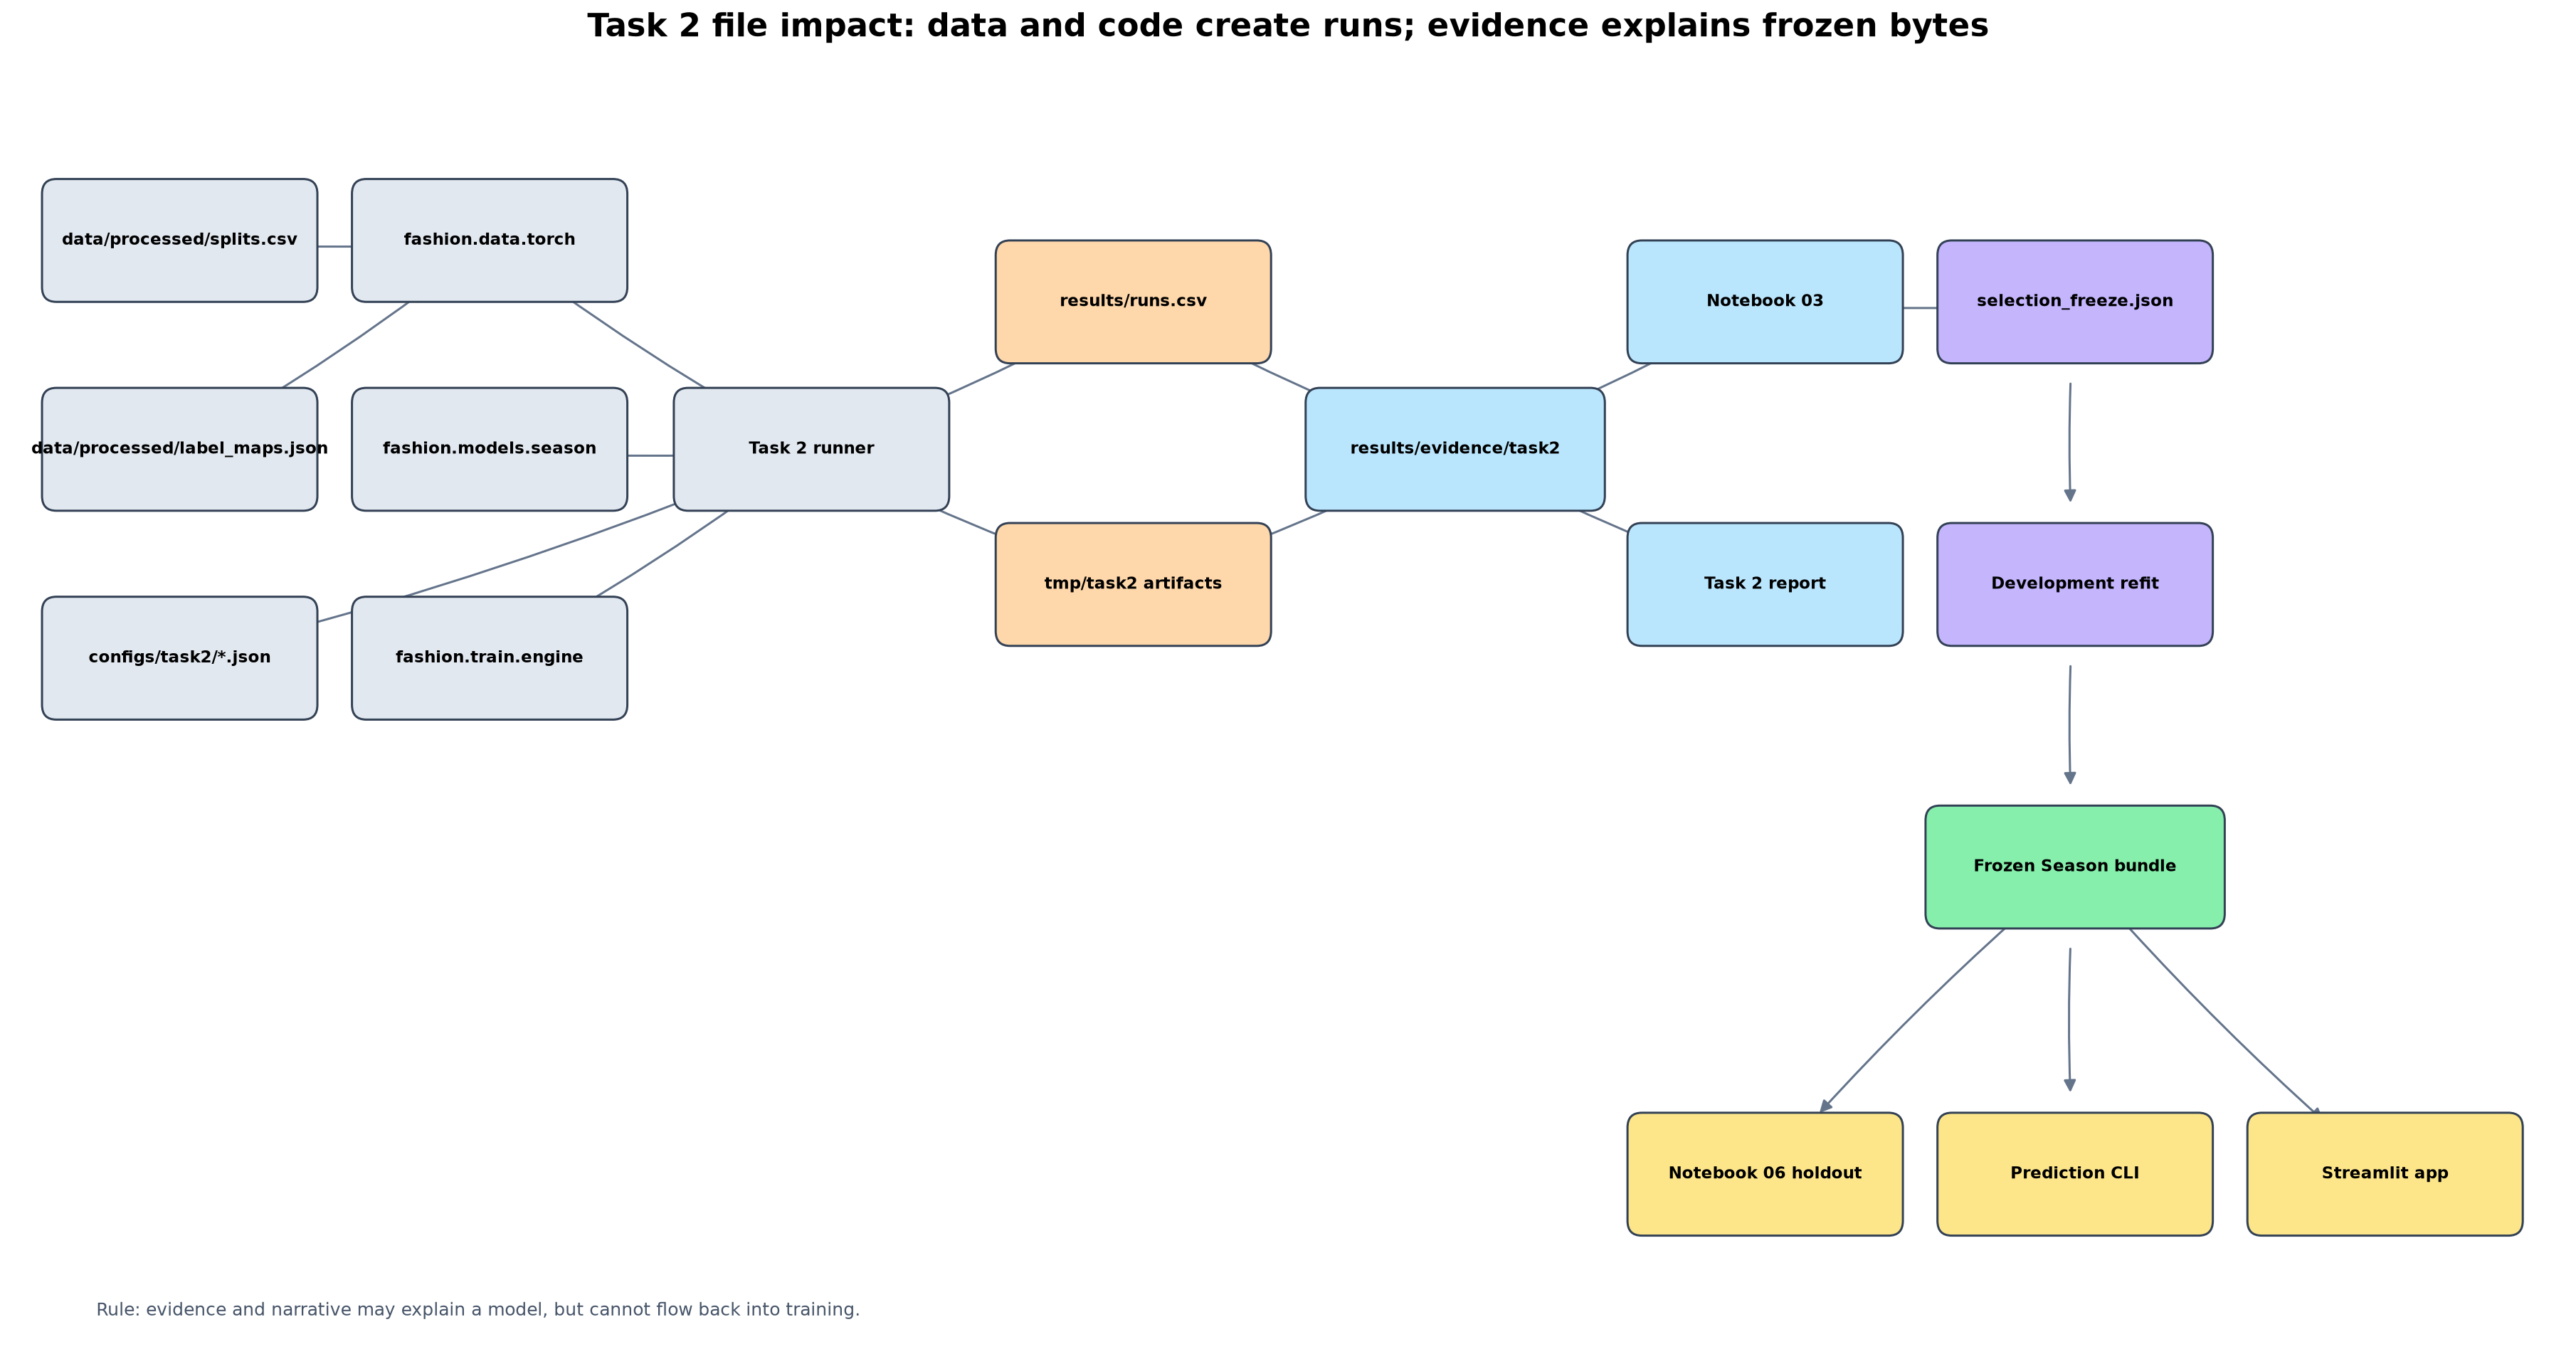

> **How to read this figure.** Arrows move one way from data and training to freeze, blind prediction, scoring, and presentation. There is no arrow from holdout results back to the model.

In [2]:
task2_file_flow = pd.DataFrame(
    [
        [
            1,
            "data/processed/splits.csv + label_maps.json + configs/task2/*.json",
            "fashion.data.torch + fashion.task2.experiments + fashion.train.engine",
            "results/runs.csv + hashed development evidence",
            "Creates comparable five-fold development runs; cannot read holdout labels",
        ],
        [
            2,
            "Five-fold OOF evidence and run IDs",
            "notebooks/04_task2_part1_season.ipynb",
            "results/evidence/task2/selection_freeze.json",
            "Freezes I2 before any Task 2 holdout score",
        ],
        [
            3,
            "selection_freeze.json + development rows",
            "fashion.task2.refit",
            "models/task2_season.pt + task2_season.manifest.json",
            "Creates one image-only frozen inference bundle",
        ],
        [
            4,
            "Frozen bundle + holdout/test images",
            "scripts/build_task2_final_evaluation.py predict",
            "holdout_predictions.csv + prediction_receipt.json + "
            "results/season_test_predictions.csv",
            "Predicts before labels; no train, tune, refit, or score",
        ],
        [
            5,
            "Committed blind receipt + internal-holdout Season labels",
            "scripts/build_task2_final_evaluation.py score --evaluation-unlocked",
            "holdout metrics, intervals, slices, robustness, figures",
            "Scores frozen predictions once; results cannot flow back to the model",
        ],
        [
            6,
            "Verified final-evaluation artifacts",
            "notebooks/05_task2_part2_final_evaluation.ipynb",
            "Executed evaluation narrative",
            "Read-only replay; full-precision files, rounded display",
        ],
        [
            7,
            "Executed Notebook 06",
            "jupyter nbconvert --to html",
            "results/notebooks/06_task2_season_evaluation.html",
            "Self-contained presentation; no model or metric change",
        ],
    ],
    columns=["Step", "Reads", "Runs", "Writes", "Boundary"],
)
show_table(
    task2_file_flow,
    "Read each row left to right: input artifact, code that consumes it, output "
    "artifact, then the boundary that prevents evaluation from changing training.",
)

file_flow_manifest = read_json(ROOT / "results/evidence/task2/file_impact_manifest.json")
file_flow_figure = ROOT / file_flow_manifest["figure_path"]
assert sha256(file_flow_figure) == file_flow_manifest["figure_sha256"]
show_figure(
    file_flow_figure,
    "Arrows move one way from data and training to freeze, blind prediction, scoring, "
    "and presentation. There is no arrow from holdout results back to the model.",
    width=1100,
)

**Interpretation.**

- **Training side:** canonical folds, label order, configs, model code, and the training engine create registered development runs. Changing any of them requires a new run ID; old evidence must not be relabelled as current.
- **Freeze side:** Notebook 03 compares OOF evidence and writes `selection_freeze.json`; the development refit then creates the exact `.pt` bundle and manifest used by every later consumer.
- **Blind-evaluation side:** the bundle predicts internal-holdout images and teacher-test images before Task 2 holdout labels enter the flow. Commit `61fab768` preserves this blind state; scoring happens only afterwards in commit `5c5dc1d`.
- **No feedback rule:** holdout metrics, error slices, robustness results, Notebook 06, and its HTML are downstream descriptions. There is deliberately no arrow back to training, temperature fitting, candidate selection, or prediction replacement.
- **Handoff rule:** `results/runs.csv` is a training ledger, while this evaluation replay reads committed hash-bound evidence. The teacher-test branch ends at `results/season_test_predictions.csv` because no teacher-test Season labels are available for scoring.
- **Trace:** the diagram is `results/figures/task2/file_impact_flow.png`; its SHA-256 and allowed edges are recorded in `results/evidence/task2/file_impact_manifest.json` and `file_impact_edges.csv`.

## 2. Frozen I2 model and provenance

### 2.1 Audit the exact model used for evaluation

The selected model is a scratch SmallCNN with a training-only ArticleType auxiliary head. ArticleType helps shape the shared representation during development, but deployment inference receives only image pixels. This distinction prevents a metadata dependency from being hidden inside the final Season prediction interface.

In [3]:
selection = read_json(ROOT / "results/evidence/task2/selection_freeze.json")
model_manifest = read_json(ROOT / "models/task2_season.manifest.json")
blind_receipt = read_json(EVIDENCE / "prediction_receipt.json")
provenance = pd.DataFrame(
    [
        ["Candidate", selection["selected_model"]["candidate"]],
        ["Family", selection["selected_model"]["model_family"]],
        ["Scratch weights", selection["selected_model"]["scratch"]],
        ["Inference inputs", ", ".join(selection["selected_model"]["inference_inputs"])],
        ["Parameters", selection["selected_model"]["parameter_count"]],
        ["Refit epochs", model_manifest["final_epoch"]],
        ["Frozen temperature", blind_receipt["model"]["temperature"]],
        ["Run ID", blind_receipt["model"]["run_id"]],
        ["Bundle SHA-256", blind_receipt["model"]["bundle_sha256"]],
    ],
    columns=["Field", "Frozen value"],
)
show_table(
    provenance,
    "These values identify the one frozen I2 bundle. Matching run ID and SHA-256 "
    "matter more than rounded display values.",
)

,Field,Frozen value
0,Candidate,I2
1,Family,smallcnn
2,Scratch weights,True
3,Inference inputs,image
4,Parameters,1206112
5,Refit epochs,24
6,Frozen temperature,1.365002
7,Run ID,task2-season-i2-refit-fall-s2753-637dd6378be9
8,Bundle SHA-256,5927eff73130acedc8015199e1df5a6c6edf64c0b45023...


> **How to read this table.** These values identify the one frozen I2 bundle. Matching run ID and SHA-256 matter more than rounded display values.

**Interpretation.**

- **Result:** evaluation uses I2 SmallCNN with 1,206,112 parameters, 24 development-refit epochs, scratch weights, image-only inference, and frozen temperature 1.3650.
- **Meaning:** the auxiliary ArticleType label affected training only. At prediction time the model cannot read ArticleType, acquisition year, file size, or the true Season label.
- **Integrity:** run `task2-season-i2-refit-fall-s2753-637dd6378be9` and bundle SHA-256 `5927eff7…` identify the exact bytes. A replacement `.pt` file fails the provenance audit instead of silently changing the result.
- **Decision:** all holdout conditions and all 5,829 teacher-test rows must use this same bundle, preprocessing contract, class order, and frozen temperature.
- **Limitation:** a development refit is one final fit, not a sixth validation fold. Its quality is justified by prior five-fold OOF and second-seed evidence, not by inspecting holdout performance during training.
- **Trace:** `results/evidence/task2/selection_freeze.json`, `models/task2_season.manifest.json`, and `prediction_receipt.json` connect selection, refit, and blind inference.

## 3. EDA-to-model selection path

### 3.1 Reconstruct the incremental B0 → B1 → C1/C2 → I1/I2 decision

Each model changes one clear assumption. B0 tests whether a classifier adds value beyond the class prior. B1 tests the EDA claim that shape and colour contain Season signal. C1/C2 test learned scratch features and capacity. I1 tests class-balanced loss. I2 tests training-only ArticleType transfer. P* estimates a pretrained ceiling but is excluded from final selection by the scratch-only assignment rule.
**Source boundary:** because this section restates earlier training choices, Section 14 repeats only the training papers needed for B1, C1/C2, I1, I2, augmentation, and P*. Methods not discussed in this evaluation notebook are not repeated.


,Model,Question answered,Development OOF macro-F1,Controlled comparison,Decision
0,B0 majority,Prior-only floor; exposes imbalance,0.1657,Starting point,Primary holdout baseline
1,B1 HOG + HSV SVM,Do hand-crafted shape and colour features carr...,0.6096,+0.4439 vs B0,Keep as serious classical baseline
2,C1 scratch SmallCNN,Can compact learned features improve B1?,0.7377,+0.1281 vs B1,Compact full-budget reference
3,C2 scratch ResNet18,Does much more model capacity clearly help?,0.7350,-0.0026 vs C1,Near tie; do not pay the size cost
4,I1 class-balanced C1,Does effective-number weighting repair rare Sp...,0.7015,-0.0362 vs C1,Reject: precision and macro-F1 fall
5,I2 multi-task C1,Does training-only ArticleType supervision imp...,0.7527,+0.0150 vs C1,Freeze as best eligible scratch model
6,P* pretrained ResNet18,How much does ImageNet initialisation add in a...,0.7542,+0.0230 vs P0S,Benchmark ceiling only; final-ineligible


> **How to read this table.** Read top to bottom as an incremental argument: prior-only floor, classical visual baseline, learned features, capacity check, targeted interventions, then the ineligible pretrained ceiling.

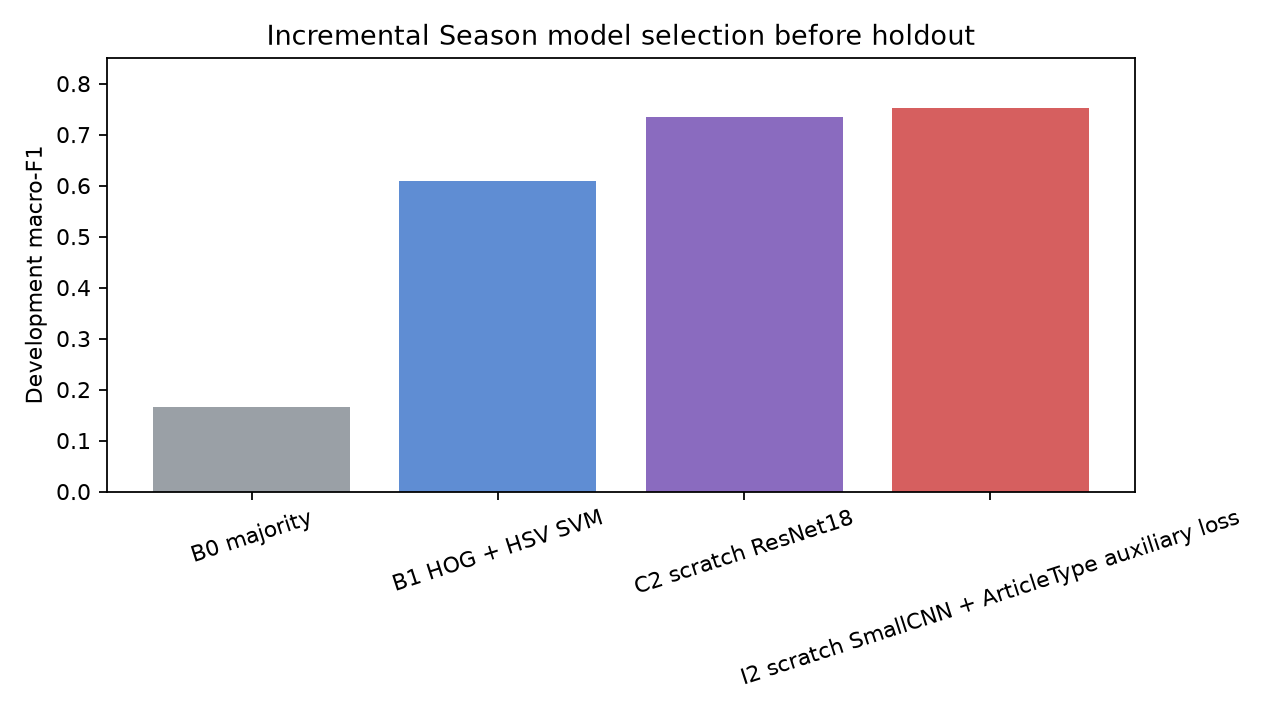

> **How to read this figure.** The bars compare development OOF macro-F1; annotations explain why a larger number did or did not make a candidate eligible.

In [4]:
metric_paths = {
    "B0 majority": "b0_majority",
    "B1 HOG + HSV SVM": "b1_hog_hsv_svm",
    "C1 scratch SmallCNN": "g3_c1_t1_smallcnn",
    "C2 scratch ResNet18": "g3_c2_t0_resnet18",
    "I1 class-balanced C1": "g4_i1_effective_number_c1",
    "I2 multi-task C1": "g4_i2_article_type_lambda_0_3_c1",
    "P0S matched scratch ResNet18": "g4_p0s_resnet18_standard_scratch",
    "P* pretrained ResNet18": "g4_pstar_resnet18_standard_pretrained",
}
development_f1 = {
    name: read_json(ROOT / "results/evidence/task2" / folder / "pooled_metrics.json")["macro_f1"]
    for name, folder in metric_paths.items()
}
b1_vs_b0 = development_f1["B1 HOG + HSV SVM"] - development_f1["B0 majority"]
c1_vs_b1 = development_f1["C1 scratch SmallCNN"] - development_f1["B1 HOG + HSV SVM"]
c2_vs_c1 = development_f1["C2 scratch ResNet18"] - development_f1["C1 scratch SmallCNN"]
i1_vs_c1 = development_f1["I1 class-balanced C1"] - development_f1["C1 scratch SmallCNN"]
i2_vs_c1 = development_f1["I2 multi-task C1"] - development_f1["C1 scratch SmallCNN"]
pstar_vs_p0s = (
    development_f1["P* pretrained ResNet18"] - development_f1["P0S matched scratch ResNet18"]
)

selection_story = pd.DataFrame(
    [
        [
            "B0 majority",
            "Prior-only floor; exposes imbalance",
            development_f1["B0 majority"],
            "Starting point",
            "Primary holdout baseline",
        ],
        [
            "B1 HOG + HSV SVM",
            "Do hand-crafted shape and colour features carry signal?",
            development_f1["B1 HOG + HSV SVM"],
            f"{b1_vs_b0:+.4f} vs B0",
            "Keep as serious classical baseline",
        ],
        [
            "C1 scratch SmallCNN",
            "Can compact learned features improve B1?",
            development_f1["C1 scratch SmallCNN"],
            f"{c1_vs_b1:+.4f} vs B1",
            "Compact full-budget reference",
        ],
        [
            "C2 scratch ResNet18",
            "Does much more model capacity clearly help?",
            development_f1["C2 scratch ResNet18"],
            f"{c2_vs_c1:+.4f} vs C1",
            "Near tie; do not pay the size cost",
        ],
        [
            "I1 class-balanced C1",
            "Does effective-number weighting repair rare Spring?",
            development_f1["I1 class-balanced C1"],
            f"{i1_vs_c1:+.4f} vs C1",
            "Reject: precision and macro-F1 fall",
        ],
        [
            "I2 multi-task C1",
            "Does training-only ArticleType supervision improve representation?",
            development_f1["I2 multi-task C1"],
            f"{i2_vs_c1:+.4f} vs C1",
            "Freeze as best eligible scratch model",
        ],
        [
            "P* pretrained ResNet18",
            "How much does ImageNet initialisation add in a matched pair?",
            development_f1["P* pretrained ResNet18"],
            f"{pstar_vs_p0s:+.4f} vs P0S",
            "Benchmark ceiling only; final-ineligible",
        ],
    ],
    columns=[
        "Model",
        "Question answered",
        "Development OOF macro-F1",
        "Controlled comparison",
        "Decision",
    ],
)
show_table(
    selection_story.round({"Development OOF macro-F1": 4}),
    "Read top to bottom as an incremental argument: prior-only floor, classical "
    "visual baseline, learned features, capacity check, targeted interventions, "
    "then the ineligible pretrained ceiling.",
)
show_figure(
    FIGURES / "development_selection_story.png",
    "The bars compare development OOF macro-F1; annotations explain why a larger "
    "number did or did not make a candidate eligible.",
)

**Interpretation.**

- **Baseline logic:** B0 scores 0.1657 macro-F1 because it predicts only the majority class. B1 rises to 0.6096 (`+0.4439`), confirming the EDA claim that shape and colour contain useful visual signal while showing that fixed HOG/HSV features leave a large representation gap.
- **Learned models:** compact C1 reaches 0.7377 (`+0.1281` over B1). Larger C2 reaches 0.7350, a `−0.0026` near tie despite about 9.51 times more parameters, so capacity alone is not a valid reason to choose it.
- **Targeted changes:** I1 falls to 0.7015 because increased Spring recall came with too many false positives. I2 reaches 0.7527 (`+0.0150` over C1) and also beats C2 at seed 2026 by 0.0116, so the gain is not limited to one seed.
- **Eligibility boundary:** P* reaches 0.7542, slightly above I2, but it uses pretrained ImageNet weights. It is honest benchmark evidence, not an eligible final model under the assignment rule.
- **Decision:** freeze I2 because it is the strongest eligible scratch candidate, improves overall and conflict-slice evidence, remains compact, and survives the second-seed check—not because it is the most complex model or the single largest displayed number.
- **Limitation:** these are development OOF comparisons. Only the already-frozen I2 and B0 can enter the one-shot holdout comparison because their predictions were frozen before unlock.

## 4. Blind predictions and teacher test output

### 4.1 Verify the pre-label receipt and two-column test file

All internal-holdout predictions and all five stress conditions were stored before Season labels were opened. The teacher test has no labels, so this notebook audits coverage only and does not claim test accuracy.


In [5]:
teacher_predictions = pd.read_csv(ROOT / "results/season_test_predictions.csv")
assert teacher_predictions.columns.tolist() == ["id", "season"]
assert len(teacher_predictions) == TEST_ROWS_EXPECTED
assert teacher_predictions["id"].is_unique
assert teacher_predictions["season"].notna().all()
blind_audit = pd.DataFrame(
    [
        ["Holdout predictions", blind_receipt["coverage"]["holdout_rows"], False],
        ["Holdout stress predictions", 5 * blind_receipt["coverage"]["holdout_rows"], False],
        ["Teacher test predictions", len(teacher_predictions), False],
    ],
    columns=["Artifact", "Rows", "Labels used for scoring"],
)
show_table(
    blind_audit,
    "All three prediction artifacts were created without labels being used for "
    "scoring; row counts prove coverage, not predictive quality.",
)
show_table(
    teacher_predictions["season"]
    .value_counts()
    .rename_axis("Predicted Season")
    .to_frame("Teacher-test rows"),
    "This is only the predicted-label mix on the hidden teacher test. Without true "
    "labels, it cannot be read as accuracy or class prevalence.",
)
print(
    {
        "file": "results/season_test_predictions.csv",
        "sha256": sha256(ROOT / "results/season_test_predictions.csv"),
    }
)

,Artifact,Rows,Labels used for scoring
0,Holdout predictions,5778,False
1,Holdout stress predictions,28890,False
2,Teacher test predictions,5829,False


> **How to read this table.** All three prediction artifacts were created without labels being used for scoring; row counts prove coverage, not predictive quality.

,Teacher-test rows
Predicted Season,
Summer,3358
Spring,1102
Winter,1101
Fall,268


> **How to read this table.** This is only the predicted-label mix on the hidden teacher test. Without true labels, it cannot be read as accuracy or class prevalence.

{'file': 'results/season_test_predictions.csv', 'sha256': '513e9e523adae5974ed8d34a34764fca15f78f735bd21196764dc4664dbdfa4a'}


**Interpretation.**

- **Result:** blind inference produced 5,778 clean holdout predictions, 28,890 stress-condition predictions, and exactly 5,829 unique teacher-test predictions with schema `id,season` and no blank Season values.
- **Blindness:** `prediction_receipt.json` records `labels_opened=false`. The stored predictions were committed before the label unlock, so the later score cannot be based on a replacement prediction file.
- **Teacher-test boundary:** the teacher file contains IDs and predicted Season only. Since its true Season labels are unavailable, this notebook reports schema, order, uniqueness, coverage, class distribution, and SHA-256—but no teacher-test accuracy or F1.
- **Decision:** hand teammates `results/season_test_predictions.csv`; do not hand-copy these labels into another file or join columns in a way that changes row order.
- **Limitation:** passing the output contract proves delivery correctness, not predictive correctness on the hidden teacher test.

## 5. One-shot internal-holdout coverage

### 5.1 Audit the unlock receipt

The unlock receipt records what was exposed and forbids retraining, retuning, winner changes, and temperature refitting after scoring.


In [6]:
unlock = read_json(EVIDENCE / "unlock_receipt.json")
coverage = evaluation_manifest["coverage"]
unlock_table = pd.DataFrame(
    [
        ["Holdout rows", unlock["holdout_rows"]],
        ["Valid Season labels", unlock["valid_season_rows"]],
        ["Blank or invalid Season labels", unlock["blank_or_invalid_season_rows"]],
        ["Quarantine rows excluded", unlock["quarantine_rows_excluded"]],
        ["Product-family groups", coverage["product_family_groups"]],
        ["Prediction failures", coverage["prediction_failures"]],
        ["Model retrained", unlock["model_retrained"]],
        ["Temperature refit", unlock["temperature_refit"]],
    ],
    columns=["Check", "Result"],
)
show_table(
    unlock_table,
    "The one-shot score uses all 5,778 valid holdout rows, excludes 61 quarantined "
    "rows, and confirms that neither model nor temperature was refitted.",
)

,Check,Result
0,Holdout rows,5778
1,Valid Season labels,5778
2,Blank or invalid Season labels,0
3,Quarantine rows excluded,61
4,Product-family groups,4110
5,Prediction failures,0
6,Model retrained,False
7,Temperature refit,False


> **How to read this table.** The one-shot score uses all 5,778 valid holdout rows, excludes 61 quarantined rows, and confirms that neither model nor temperature was refitted.

**Interpretation.**

- **Result:** all 5,778 holdout rows have valid Season labels and predictions; zero rows are dropped, zero image reads fail, and all 61 quarantine rows are excluded. The holdout contains 4,110 product-family groups.
- **Meaning:** 100% coverage prevents an inflated score caused by silently skipping corrupt or difficult examples. Quarantine exclusion follows the shared split contract rather than an after-the-fact quality choice.
- **Decision:** score the full valid holdout once, then analyse its fixed predictions. The unlock receipt forbids retraining, retuning, winner changes, temperature refitting, or replacing predictions.
- **Uncertainty link:** the 4,110 family groups become the resampling units in Section 8 so repeated product rows do not pretend to be independent observations.
- **Limitation:** valid coverage does not mean every label is visually unambiguous, and same-source rows do not represent every future image condition.

## 6. Independent scorecard and generalisation

### 6.1 Compare I2 with B0 and with development OOF

Macro-F1 is primary because the large Summer class would make accuracy alone misleading.


,model,role,accuracy,balanced_accuracy,macro_f1,weighted_f1,development_macro_f1,holdout_minus_development_macro_f1
0,B0 majority,primary prior baseline,0.4958,0.2500,0.1657,0.3287,0.1657,0.0000
1,I2 frozen,ultimate judgement,0.7643,0.7197,0.7534,0.7623,0.7527,0.0007


> **How to read this table.** Compare macro-F1 and balanced accuracy before raw accuracy; B0 demonstrates why majority-class accuracy is misleading under imbalance.

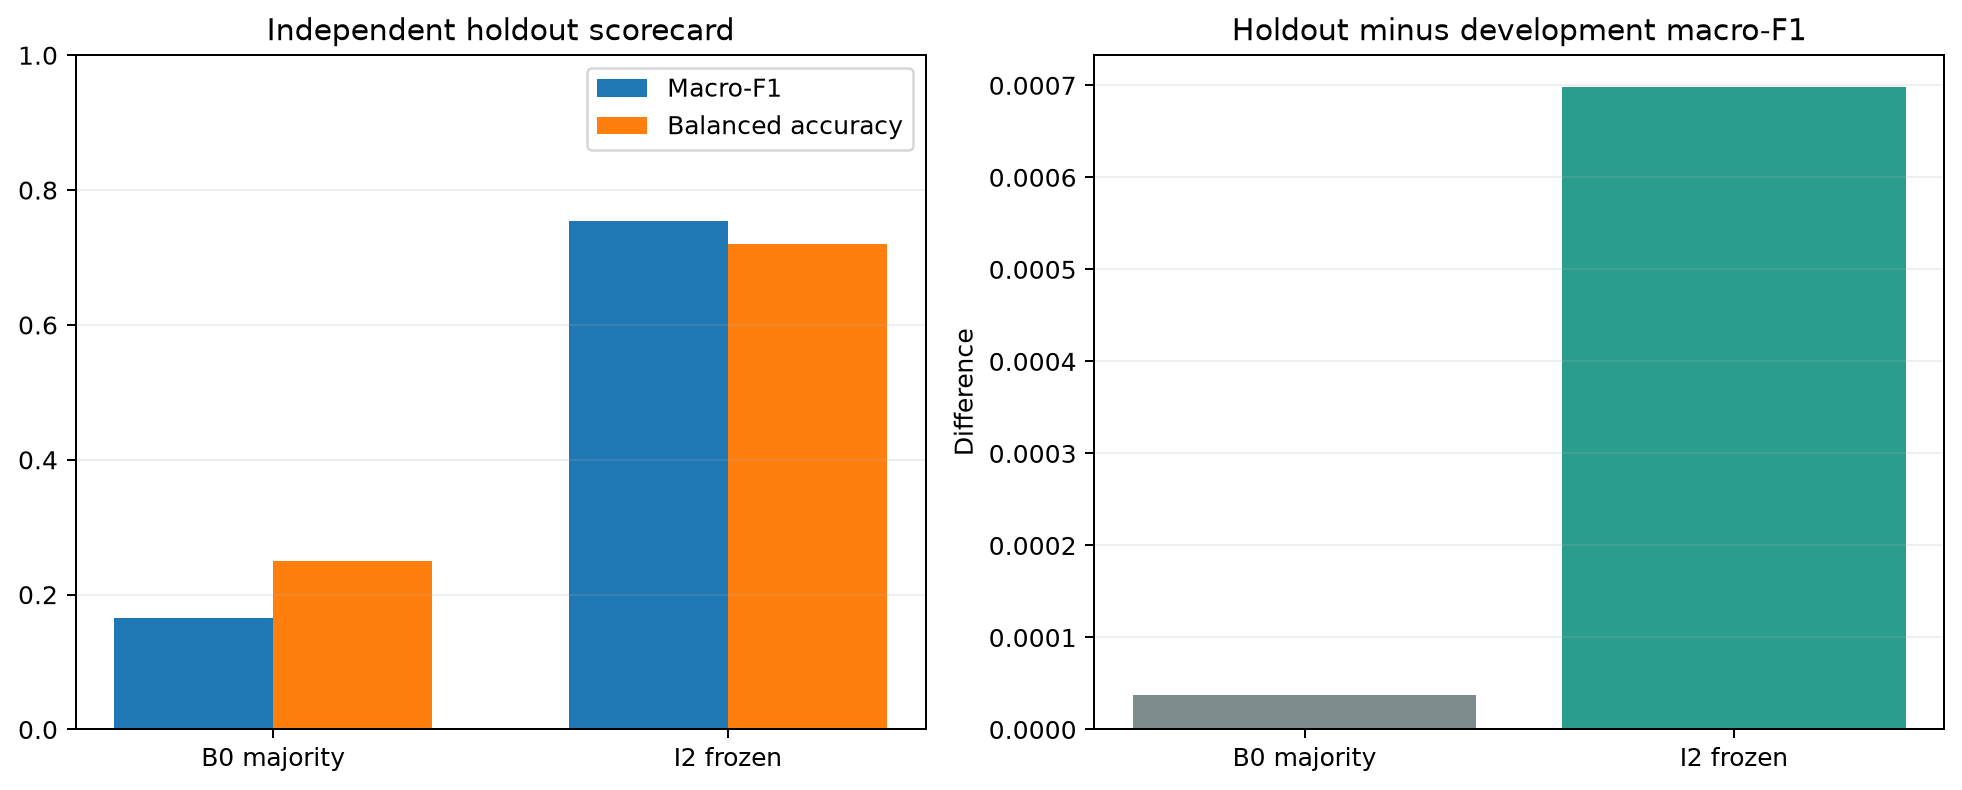

> **How to read this figure.** The visual separates the trivial B0 floor from frozen I2 and shows the small development-to-holdout change for I2.

In [7]:
holdout_scorecard = pd.read_csv(EVIDENCE / "holdout_scorecard.csv")
score_columns = [
    "model",
    "role",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "development_macro_f1",
    "holdout_minus_development_macro_f1",
]
show_table(
    holdout_scorecard.loc[:, score_columns].round(4),
    "Compare macro-F1 and balanced accuracy before raw accuracy; B0 demonstrates "
    "why majority-class accuracy is misleading under imbalance.",
)
show_figure(
    FIGURES / "holdout_scorecard.png",
    "The visual separates the trivial B0 floor from frozen I2 and shows the small "
    "development-to-holdout change for I2.",
)

**Interpretation.**

- **Result:** I2 obtains 0.7534 macro-F1, 0.7197 balanced accuracy, and 0.7643 accuracy. B0 obtains 0.1657 macro-F1, 0.2500 balanced accuracy, and 0.4958 accuracy.
- **Why macro-F1 matters:** B0 is almost 50% accurate only because Summer forms about half of the holdout, yet it gives Fall, Spring, and Winter an F1 of zero. Accuracy alone would greatly overstate usefulness.
- **Generalisation check:** I2 holdout macro-F1 is only `+0.0007` above its 0.7527 development OOF score. This is evidence of no material same-source collapse, not evidence that the model will keep the same score under a new domain.
- **Decision:** I2 clearly beats the prior-only baseline and is suitable for deeper failure analysis. Keep the judgement conditional because balanced accuracy remains below raw accuracy and important slices fail later.
- **Precision:** the displayed values are rounded to four decimals; the stored comparison uses full-precision values 0.7533847968563716 and 0.7526869559580971.

## 7. Per-class behaviour and confusion

### 7.1 Inspect each Season and the largest error routes

Fixed class order is retained even for small slices, so weak classes cannot disappear from the average.


,model,label,support,precision,recall,f1
4,I2 frozen,Fall,1575,0.7419,0.6571,0.6970
5,I2 frozen,Spring,233,0.9484,0.6309,0.7577
6,I2 frozen,Summer,2865,0.7646,0.8387,0.7999
7,I2 frozen,Winter,1105,0.7659,0.7520,0.7589


> **How to read this table.** Support shows class sample size; precision and recall reveal different failure types that one macro-F1 value would hide.

,y_true,y_pred,count,mean_confidence,high_confidence_count
0,Fall,Summer,463,0.657,105
1,Summer,Fall,294,0.618,45
2,Winter,Summer,229,0.617,40
3,Summer,Winter,161,0.601,24
4,Fall,Winter,76,0.575,11
5,Spring,Summer,48,0.629,6


> **How to read this table.** Rows are directional mistakes, so Fall → Summer is different from Summer → Fall. Count gives frequency and confidence shows how hard review may be.

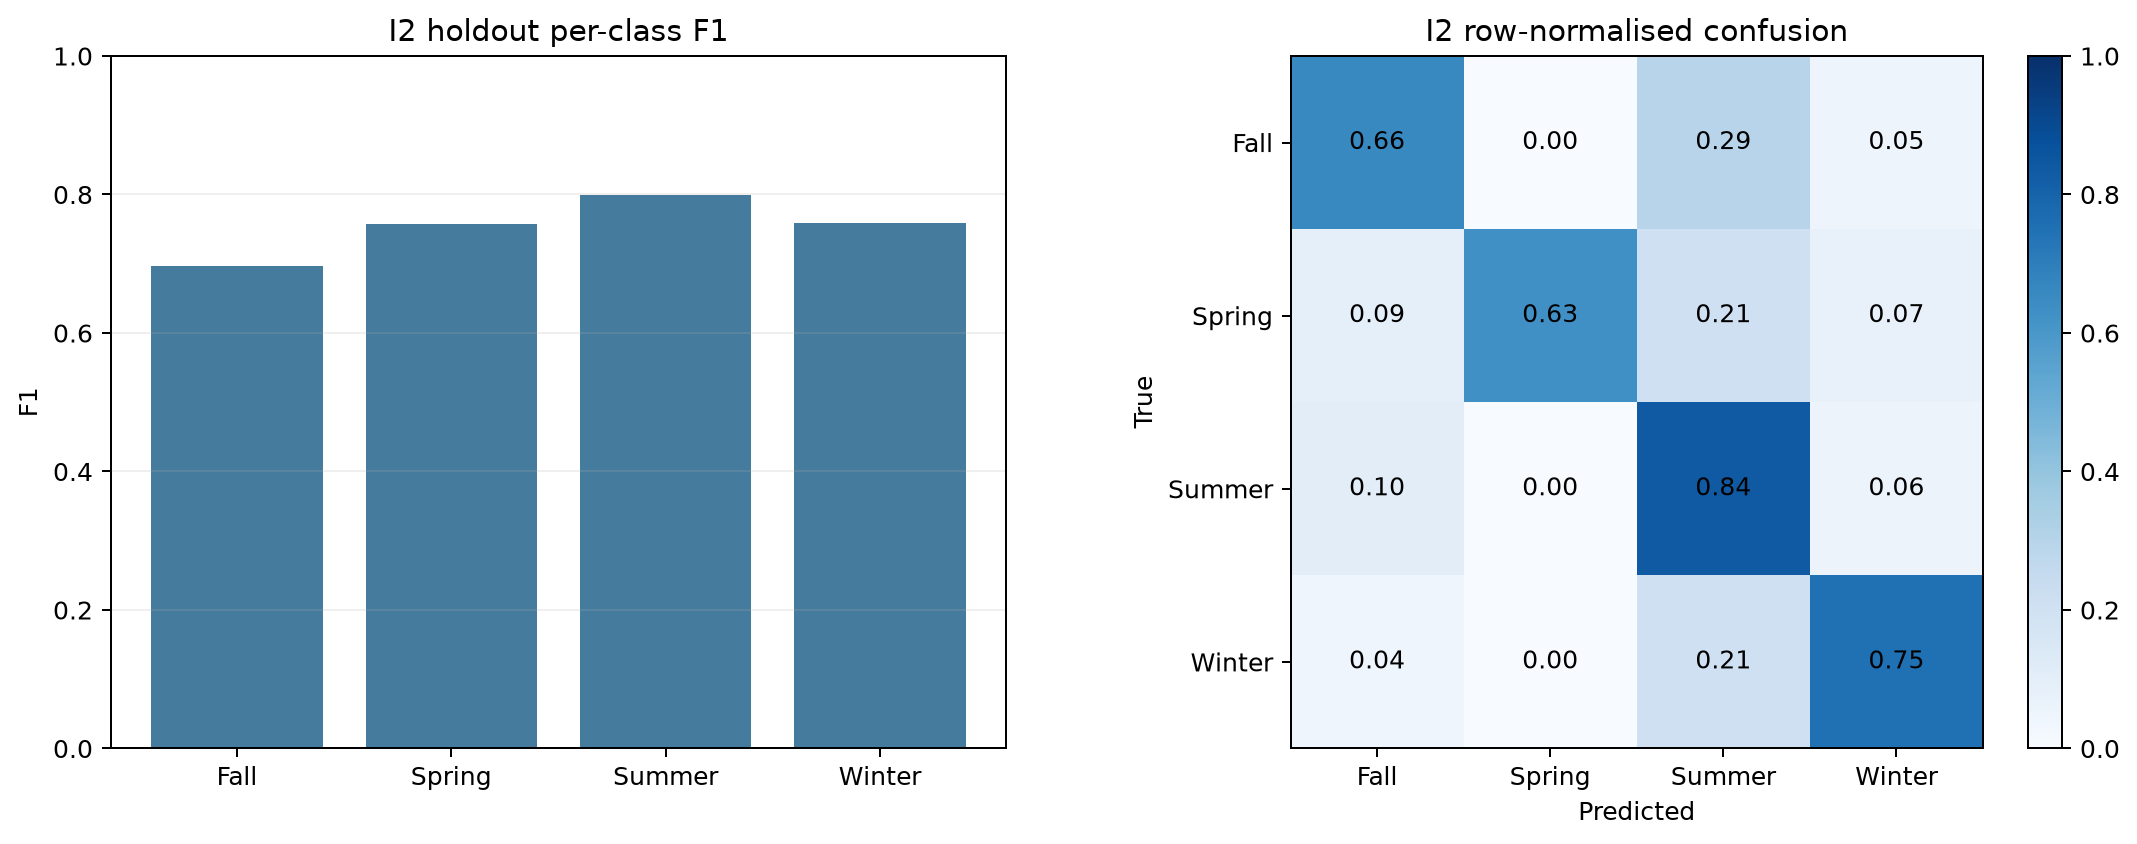

> **How to read this figure.** Use the class bars for per-class quality and each confusion-matrix row for the destination of one true class.

In [8]:
per_class = pd.read_csv(EVIDENCE / "holdout_per_class.csv")
error_routes = pd.read_csv(EVIDENCE / "holdout_error_routes.csv")
show_table(
    per_class.loc[per_class["model"].eq("I2 frozen")].round(4),
    "Support shows class sample size; precision and recall reveal different failure "
    "types that one macro-F1 value would hide.",
)
show_table(
    error_routes.head(6).round({"mean_confidence": 3}),
    "Rows are directional mistakes, so Fall → Summer is different from Summer → "
    "Fall. Count gives frequency and confidence shows how hard review may be.",
)
show_figure(
    FIGURES / "holdout_per_class_confusion.png",
    "Use the class bars for per-class quality and each confusion-matrix row for the "
    "destination of one true class.",
)

**Interpretation.**

- **Class results:** F1 is 0.6970 for Fall, 0.7577 for Spring, 0.7999 for Summer, and 0.7589 for Winter. Fall is the weakest clean class, so the earlier belief that rare Spring must be weakest is not supported.
- **Spring trade-off:** Spring precision is very high at 0.9484, but recall is only 0.6309. The model is cautious when predicting Spring: most Spring predictions are correct, but about 37% of true Spring rows are missed.
- **Error routes:** Fall → Summer is the largest route with 463 errors, followed by Summer → Fall with 294. These directions expose a Fall/Summer boundary problem that a single macro average cannot show.
- **Decision:** prioritise human review for Fall/Summer ambiguity and low-confidence Spring omissions; do not optimise only the already-strong majority-class Summer F1.
- **Limitation:** a confusion matrix states what was confused, not why. ArticleType, image quality, and ambiguous Season concepts are hypotheses tested separately, not causes proven by this table.

## 8. Product-family blocked uncertainty

### 8.1 Inspect the 10,000-draw distributions and 95% bootstrap intervals

Related images in one product family are resampled together. The notebook deterministically reconstructs the actual 10,000 resampled values from the frozen predictions, checks their quantiles against the hash-verified interval artifact, and then shows both a histogram and a KDE curve. The histogram is the evidence; KDE is only a smooth visual guide.

,Metric,2.5%,Median,97.5%,Width,Reference
0,I2 macro-F1,0.7333,0.7532,0.7720,0.0387,absolute score
1,I2 − B0 macro-F1,0.5667,0.5875,0.6072,0.0406,0 = no gain
2,I2 accuracy,0.7512,0.7642,0.7774,0.0261,absolute score
3,I2 Spring F1,0.6947,0.7577,0.8123,0.1177,absolute score


> **How to read this table.** The middle 95% is bounded by the empirical 2.5th and 97.5th percentiles. Only the I2 − B0 row is an effect contrast, so zero is meaningful only for that row. Width measures resampling uncertainty, not the classifier's error rate.

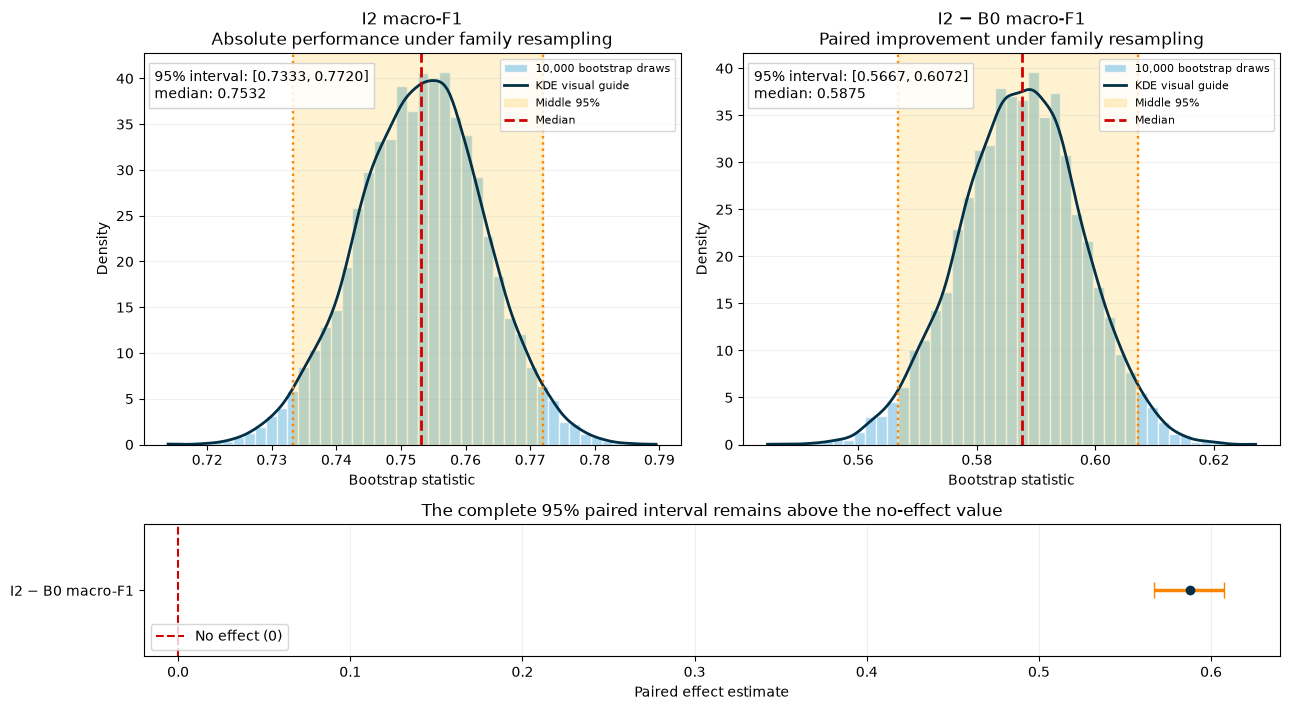

> **How to read this figure.** Each histogram uses the actual 10,000 family-blocked draws. The blue curve is a KDE smoothing aid; it does not set the interval. Orange marks the empirical middle 95%, red dashed lines mark medians, and the bottom panel compares the paired improvement with the no-effect value 0.

In [9]:
bootstrap = pd.read_csv(EVIDENCE / "holdout_bootstrap_intervals.csv")
scored_bootstrap = pd.read_csv(EVIDENCE / "holdout_predictions_and_labels.csv")
bootstrap_draws = paired_group_bootstrap(
    scored_bootstrap["actual_season"].astype(str).to_numpy(),
    scored_bootstrap["product_family_group"].astype(str).to_numpy(),
    {
        "I2_minus_B0": (
            scored_bootstrap["b0_prediction"].astype(str).to_numpy(),
            scored_bootstrap["i2_prediction"].astype(str).to_numpy(),
        )
    },
    labels=LABELS,
    replicates=10_000,
    random_seed=2_753,
)

metric_columns = {
    "i2_macro_f1": "model_b_macro_f1",
    "i2_minus_b0_macro_f1": "b_minus_a_macro_f1",
    "i2_accuracy": "model_b_accuracy",
    "i2_spring_f1": "model_b_f1_spring",
}
metric_labels = {
    "i2_macro_f1": "I2 macro-F1",
    "i2_minus_b0_macro_f1": "I2 − B0 macro-F1",
    "i2_accuracy": "I2 accuracy",
    "i2_spring_f1": "I2 Spring F1",
}
interval_rows = []
for metric, draw_column in metric_columns.items():
    recorded = bootstrap.loc[bootstrap["metric"].eq(metric)].iloc[0]
    quantiles = np.quantile(
        bootstrap_draws[draw_column].to_numpy(dtype=float),
        [0.025, 0.5, 0.975],
    )
    np.testing.assert_allclose(
        quantiles,
        recorded[["lower_95", "median", "upper_95"]].to_numpy(dtype=float),
        rtol=0.0,
        atol=1e-12,
    )
    interval_rows.append(
        {
            "Metric": metric_labels[metric],
            "2.5%": quantiles[0],
            "Median": quantiles[1],
            "97.5%": quantiles[2],
            "Width": quantiles[2] - quantiles[0],
            "Reference": "0 = no gain" if "minus" in metric else "absolute score",
        }
    )
interval_reading = pd.DataFrame(interval_rows)
show_table(
    interval_reading.round(4),
    "The middle 95% is bounded by the empirical 2.5th and 97.5th percentiles. "
    "Only the I2 − B0 row is an effect contrast, so zero is meaningful only for that row. "
    "Width measures resampling uncertainty, not the classifier's error rate.",
)

distribution_specs = (
    (
        "model_b_macro_f1",
        "I2 macro-F1",
        "Absolute performance under family resampling",
    ),
    (
        "b_minus_a_macro_f1",
        "I2 − B0 macro-F1",
        "Paired improvement under family resampling",
    ),
)
figure = plt.figure(figsize=(13, 7.2))
grid = figure.add_gridspec(2, 2, height_ratios=[4, 1.35])
for index, (column, title, subtitle) in enumerate(distribution_specs):
    axis = figure.add_subplot(grid[0, index])
    values = bootstrap_draws[column].to_numpy(dtype=float)
    lower, median, upper = np.quantile(values, [0.025, 0.5, 0.975])
    axis.hist(
        values,
        bins=45,
        density=True,
        color="#8ecae6",
        edgecolor="white",
        alpha=0.72,
        label="10,000 bootstrap draws",
    )
    x_grid = np.linspace(values.min(), values.max(), 400)
    axis.plot(
        x_grid,
        gaussian_kde(values)(x_grid),
        color="#023047",
        linewidth=2,
        label="KDE visual guide",
    )
    axis.axvspan(lower, upper, color="#ffb703", alpha=0.18, label="Middle 95%")
    axis.axvline(lower, color="#fb8500", linestyle=":", linewidth=1.7)
    axis.axvline(median, color="#d00000", linestyle="--", linewidth=2, label="Median")
    axis.axvline(upper, color="#fb8500", linestyle=":", linewidth=1.7)
    axis.set_title(f"{title}\n{subtitle}")
    axis.set_xlabel("Bootstrap statistic")
    axis.set_ylabel("Density")
    axis.grid(axis="y", alpha=0.18)
    axis.text(
        0.02,
        0.96,
        f"95% interval: [{lower:.4f}, {upper:.4f}]\nmedian: {median:.4f}",
        transform=axis.transAxes,
        va="top",
        bbox={"facecolor": "white", "alpha": 0.86, "edgecolor": "#cccccc"},
    )
    axis.legend(loc="upper right", fontsize=8)

contrast_axis = figure.add_subplot(grid[1, :])
contrast = interval_reading.loc[
    interval_reading["Metric"].eq("I2 − B0 macro-F1")
].iloc[0]
contrast_axis.errorbar(
    contrast["Median"],
    0,
    xerr=np.array(
        [
            [contrast["Median"] - contrast["2.5%"]],
            [contrast["97.5%"] - contrast["Median"]],
        ]
    ),
    fmt="o",
    color="#023047",
    ecolor="#fb8500",
    capsize=6,
    linewidth=2.5,
)
contrast_axis.axvline(0, color="#d00000", linestyle="--", label="No effect (0)")
contrast_axis.set_xlim(-0.02, 0.64)
contrast_axis.set_yticks([0], ["I2 − B0 macro-F1"])
contrast_axis.set_xlabel("Paired effect estimate")
contrast_axis.set_title("The complete 95% paired interval remains above the no-effect value")
contrast_axis.grid(axis="x", alpha=0.18)
contrast_axis.legend(loc="lower left")
figure.tight_layout()
plt.show()
display(
    Markdown(
        "> **How to read this figure.** Each histogram uses the actual 10,000 "
        "family-blocked draws. The blue curve is a KDE smoothing aid; it does not "
        "set the interval. Orange marks the empirical middle 95%, red dashed lines "
        "mark medians, and the bottom panel compares the paired improvement with "
        "the no-effect value 0."
    )
)


**Interpretation.**

- **What the distribution adds:** the histogram shows how the statistic changes across the actual 10,000 product-family resamples. The KDE line only makes the shape easier to see; all reported endpoints come from empirical quantiles, not from the smoothed curve.
- **Method:** each draw resamples the 4,110 product families rather than individual rows. This keeps related catalogue rows together and avoids treating repeated products as independent evidence.
- **Result:** I2 macro-F1 has a 95% family-blocked percentile interval of [0.7333, 0.7720]. The paired I2-minus-B0 interval is [0.5667, 0.6072], entirely above the no-effect value zero.
- **Minority uncertainty:** Spring F1 has the wider interval [0.6947, 0.8123], which is expected from only 233 holdout examples. A point estimate alone hides that instability.
- **P-value decision:** **No p-value is reported.** The predeclared analysis is an effect size with a paired family-blocked 95% bootstrap interval. A p-value would require a separate null-generating test, such as a family-blocked paired permutation test, defined before looking at the holdout. Counting ordinary bootstrap draws below zero is not silently relabelled as a p-value.
- **Decision:** because the paired interval stays above zero, the I2-over-B0 conclusion is stable under this resampling design. For a future close finalist comparison, predeclare the paired permutation test and any multiple-comparison correction before evaluation.
- **Limitation:** this interval describes resampling uncertainty under a conservative proxy grouping. It is not the model error rate, the probability that a fixed true score lies inside this realised interval, or a guarantee for a new retailer or distribution.

## 9. Calibration and selective review

### 9.1 Compare raw and frozen-temperature confidence

Temperature scaling may change confidence but must not change the predicted class. Risk-coverage ranks examples by confidence; it is diagnostic because no business-cost threshold was selected.


,variant,support,accuracy,macro_f1,nll,brier,ece,mean_confidence,delta_nll_vs_raw,delta_brier_vs_raw,delta_ece_vs_raw,delta_mean_confidence_vs_raw
0,raw,5778,0.7643,0.7534,0.6314,0.3364,0.0476,0.8117,0.0000,0.0000,0.0000,0.0000
1,frozen_temperature,5778,0.7643,0.7534,0.6045,0.3331,0.0195,0.7549,-0.0269,-0.0033,-0.0281,-0.0568


> **How to read this table.** Temperature scaling should leave label metrics unchanged; lower NLL, Brier, and ECE indicate better probability alignment.

,review_budget,coverage,selective_accuracy,selective_macro_f1,confidence_threshold
6,0.0,1.0000,0.7643,0.7534,0.2952
7,0.1,0.9001,0.8002,0.8008,0.4876
8,0.2,0.8001,0.8300,0.8298,0.5575
11,0.5,0.5000,0.9079,0.9133,0.7841


> **How to read this table.** A larger review budget lowers automatic coverage and raises accepted-case quality; it does not make reviewed cases disappear.

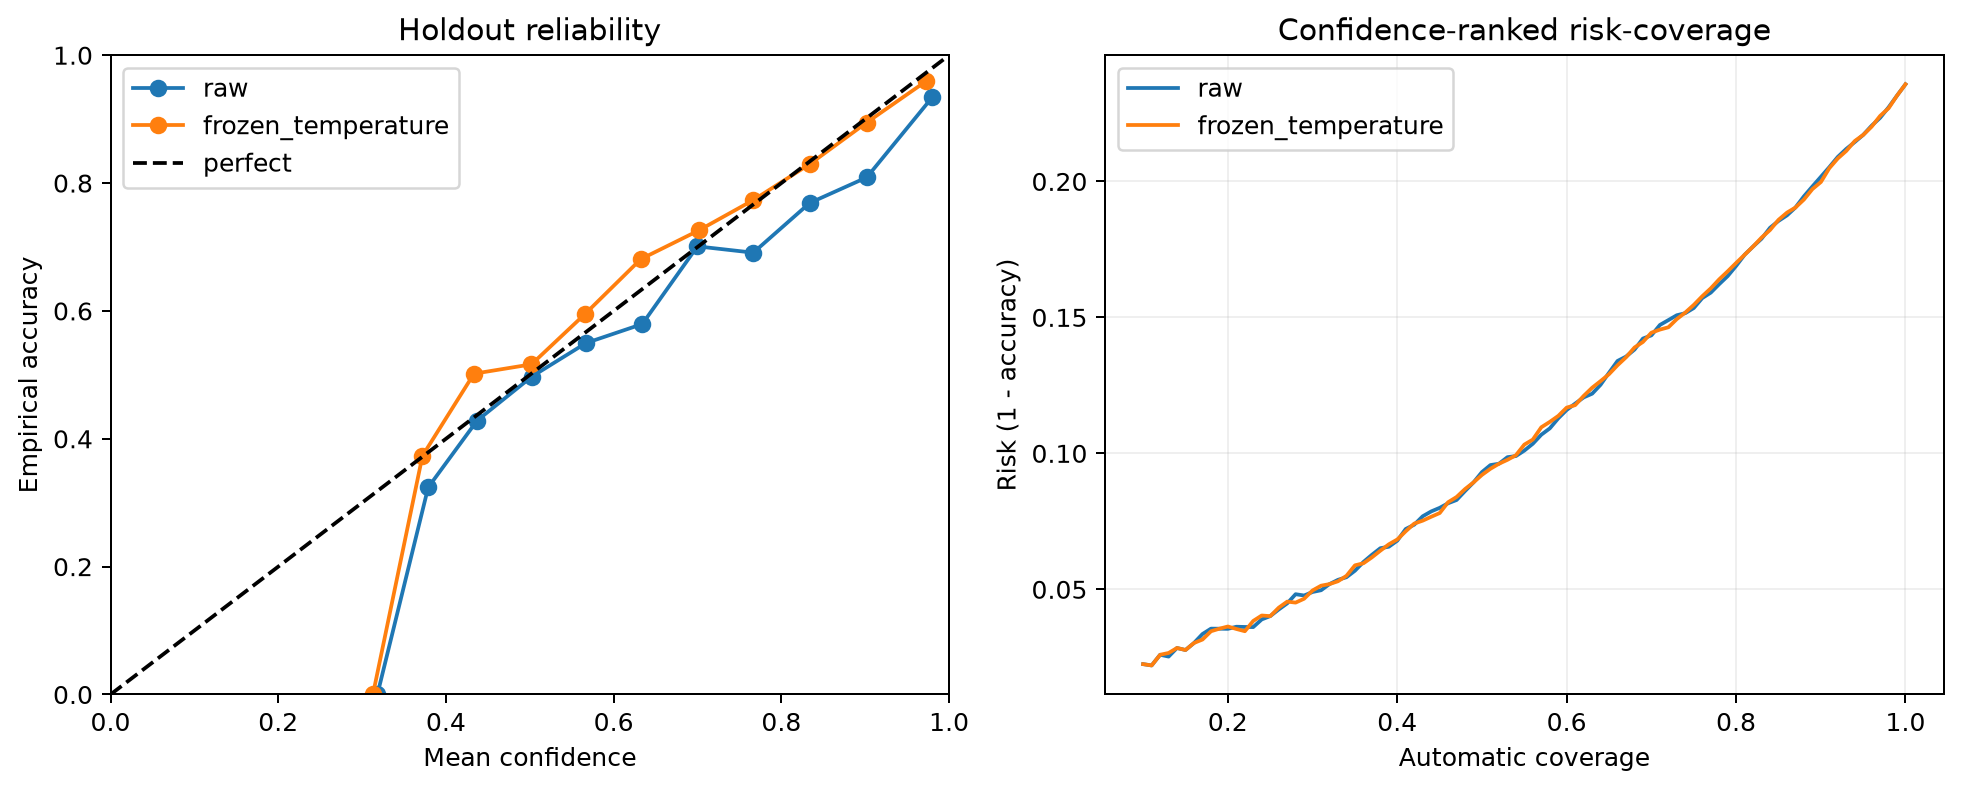

> **How to read this figure.** The reliability panel compares confidence with observed accuracy; the risk–coverage panel shows the error cost of automating more cases.

In [10]:
calibration = pd.read_csv(EVIDENCE / "holdout_calibration_summary.csv")
review_budgets = pd.read_csv(EVIDENCE / "holdout_review_budgets.csv")
budget_focus = review_budgets.loc[
    review_budgets["variant"].eq("frozen_temperature")
    & review_budgets["review_budget"].isin([0.0, 0.1, 0.2, 0.3, 0.5]),
    [
        "review_budget",
        "coverage",
        "selective_accuracy",
        "selective_macro_f1",
        "confidence_threshold",
    ],
]
show_table(
    calibration.round(4),
    "Temperature scaling should leave label metrics unchanged; lower NLL, Brier, and "
    "ECE indicate better probability alignment.",
)
show_table(
    budget_focus.round(4),
    "A larger review budget lowers automatic coverage and raises accepted-case "
    "quality; it does not make reviewed cases disappear.",
)
show_figure(
    FIGURES / "holdout_calibration_risk.png",
    "The reliability panel compares confidence with observed accuracy; the risk–"
    "coverage panel shows the error cost of automating more cases.",
)

**Interpretation.**

- **Result:** frozen temperature scaling leaves accuracy and macro-F1 unchanged, as expected because it does not change the winning class. It reduces NLL from 0.6314 to 0.6045, Brier score from 0.3364 to 0.3331, ECE from 0.0476 to 0.0195, and mean confidence from 0.8117 to 0.7549.
- **Meaning:** the raw model is overconfident on average. Temperature scaling makes probability values better aligned with observed correctness without pretending to improve classification.
- **Selective review:** retaining the top 80% by calibrated confidence gives 0.8300 accepted-case accuracy; retaining 50% gives 0.9079. This shows useful ranking, but it leaves 20% or 50% for human review.
- **Decision:** use confidence as a review-priority signal. Do not choose a production threshold from this holdout table; a threshold needs a predeclared business error cost and review capacity.
- **Limitation:** ECE depends on binning, and calibration can drift under shift—as the brightness tests warn. A calibrated probability is not certainty.

## 10. EDA reflection and predeclared slices

### 10.1 Test which EDA expectations survived independent evaluation

Slice metadata is used only after prediction for diagnosis. It is never supplied to the inference model.


In [11]:
slices = pd.read_csv(EVIDENCE / "holdout_slice_metrics.csv")


def slice_value(family, name, metric="macro_f1"):
    return slices.loc[
        slices["slice_family"].eq(family) & slices["slice_name"].eq(name), metric
    ].iloc[0]


aligned = slice_value("article_type_shortcut", "aligned")
conflict = slice_value("article_type_shortcut", "conflict")
dominant_years = slice_value("acquisition_year", "dominant_2011_2012")
other_years = slice_value("acquisition_year", "other_years")
multirow = slice_value("product_family_size", "multirow")
singleton = slice_value("product_family_size", "singleton")

reflection = pd.DataFrame(
    [
        [
            "Spring will be the weakest clean class",
            "Not supported",
            "Spring F1 0.7577; Fall F1 0.6970",
        ],
        [
            "ArticleType can become a shortcut",
            "Supported",
            f"aligned {aligned:.3f} vs conflict {conflict:.3f}",
        ],
        [
            "The dominant 2011–2012 mix may hide shift",
            "Supported with confounding",
            f"dominant {dominant_years:.3f} vs other years {other_years:.3f}",
        ],
        [
            "File size maps monotonically to difficulty",
            "Not supported",
            "Quartile macro-F1 is non-monotonic",
        ],
        [
            "Greyscale images are risky",
            "Directional only",
            f"macro-F1 {slice_value('image_mode', 'greyscale'):.3f}, but n=49",
        ],
        [
            "Multirow families inflate the main result",
            "Limited evidence",
            f"multirow {multirow:.3f} vs singleton {singleton:.3f}",
        ],
    ],
    columns=["EDA expectation", "Holdout verdict", "Evidence"],
)
show_table(
    reflection,
    "Each EDA belief is marked supported, contradicted, or uncertain using frozen "
    "holdout evidence rather than being repeated as fact.",
)
show_table(
    slices.round(4),
    "Compare rows only within the same slice family and inspect n_samples before "
    "treating a gap as stable; these are descriptive audits, not causal effects.",
)

,EDA expectation,Holdout verdict,Evidence
0,Spring will be the weakest clean class,Not supported,Spring F1 0.7577; Fall F1 0.6970
1,ArticleType can become a shortcut,Supported,aligned 0.856 vs conflict 0.446
2,The dominant 2011–2012 mix may hide shift,Supported with confounding,dominant 0.560 vs other years 0.697
3,File size maps monotonically to difficulty,Not supported,Quartile macro-F1 is non-monotonic
4,Greyscale images are risky,Directional only,"macro-F1 0.468, but n=49"
5,Multirow families inflate the main result,Limited evidence,multirow 0.759 vs singleton 0.742


> **How to read this table.** Each EDA belief is marked supported, contradicted, or uncertain using frozen holdout evidence rather than being repeated as fact.

,slice_family,slice_name,support,low_support,labels_present,accuracy,balanced_accuracy,macro_f1,nll,brier,ece,mean_confidence,recall_Fall,recall_Spring,recall_Summer,recall_Winter
0,article_type_shortcut,aligned,3746,False,4,0.8737,0.8977,0.8564,0.3669,0.1998,0.0816,0.7927,0.8655,0.9272,0.8541,0.9440
1,article_type_shortcut,conflict,2032,False,4,0.5625,0.4679,0.4462,1.0426,0.5787,0.1228,0.6853,0.5840,0.0854,0.7174,0.4848
2,acquisition_year,dominant_2011_2012,4097,False,4,0.7669,0.5735,0.5600,0.5921,0.3341,0.0284,0.7482,0.6735,0.1818,0.8400,0.5986
3,acquisition_year,other_years,1681,False,4,0.7579,0.6925,0.6971,0.6349,0.3305,0.0225,0.7711,0.4583,0.7050,0.8313,0.7756
4,file_size_quartile,q1_smallest,1502,False,4,0.7770,0.6914,0.7314,0.5435,0.3157,0.0258,0.7714,0.7857,0.4167,0.7668,0.7962
5,file_size_quartile,q2,1413,False,4,0.7580,0.6784,0.7169,0.6566,0.3568,0.0394,0.7580,0.6192,0.5143,0.8646,0.7156
6,file_size_quartile,q3,1445,False,4,0.7239,0.6659,0.6941,0.6885,0.3731,0.0280,0.7192,0.4105,0.7000,0.8189,0.7340
7,file_size_quartile,q4_largest,1418,False,4,0.7983,0.7120,0.7467,0.5318,0.2870,0.0326,0.7708,0.4886,0.7059,0.8807,0.7729
8,product_family_size,multirow,2373,False,4,0.7821,0.7213,0.7588,0.5825,0.3191,0.0356,0.7635,0.6791,0.5625,0.8396,0.8040
9,product_family_size,singleton,3405,False,4,0.7518,0.7096,0.7421,0.6199,0.3428,0.0141,0.7489,0.6430,0.6568,0.8382,0.7004


> **How to read this table.** Compare rows only within the same slice family and inspect n_samples before treating a gap as stable; these are descriptive audits, not causal effects.

**Interpretation.**

- **Supported EDA insights:** class imbalance made B0 accuracy misleading; B1 proved that shape and colour contain signal; learned features beat fixed HOG/HSV; and the ArticleType–Season relation was useful enough for I2 to improve C1 at seed 2753 and C2 at both seeds 2753 and 2026. The two-seed comparison is I2 versus C2; it does not establish a two-seed gain over C1.
- **Shortcut warning confirmed:** ArticleType-aligned rows score 0.8564 macro-F1, while conflict rows fall to 0.4462 and conflict Spring recall to 0.0854. Auxiliary learning helped development conflict rows, but the final model still depends strongly on related visual structure.
- **Mixed or contradicted insights:** Spring is not the weakest clean class; more capacity, a larger input, extra colour jitter, and effective-number class weighting did not improve the frozen development decision. File-size difficulty is non-monotonic: q3 is weakest (0.6941) while q4 is strongest (0.7467).
- **Acquisition and family checks:** dominant 2011–2012 rows have lower macro-F1 (0.5600) than other years (0.6971), despite similar raw accuracy. Multirow families score 0.7588 versus 0.7421 for singletons, a modest gap that the grouped bootstrap addresses.
- **Low-support warning:** greyscale macro-F1 is 0.4683 versus RGB 0.7545, but only 49 greyscale rows are present. This is a review signal, not a stable population estimate.
- **Decision:** keep ArticleType conflict, acquisition era, file size, family size, and image mode as post-prediction audits only. None becomes an inference feature, and none proves causation.

## 11. Robustness under image shift

### 11.1 Evaluate the five frozen image conditions

Each perturbation was declared and predicted before labels were opened. The same model, normalisation, and temperature are used throughout.


,condition,accuracy,balanced_accuracy,macro_f1,spring_recall,prediction_agreement_with_clean,delta_macro_f1_vs_clean
0,brightness_0_85,0.5554,0.3687,0.3712,0.0043,0.6125,-0.3822
1,brightness_1_15,0.7013,0.6252,0.6675,0.4678,0.8453,-0.0859
2,clean,0.7643,0.7197,0.7534,0.6309,1.0000,0.0000
3,gaussian_blur_radius_1,0.6869,0.6791,0.6840,0.6137,0.7786,-0.0694
4,jpeg_quality_85,0.7361,0.7149,0.7382,0.6223,0.8785,-0.0152


> **How to read this table.** Read delta_macro_f1_vs_clean as the loss from the same frozen model under one synthetic condition; agreement shows how often labels change.

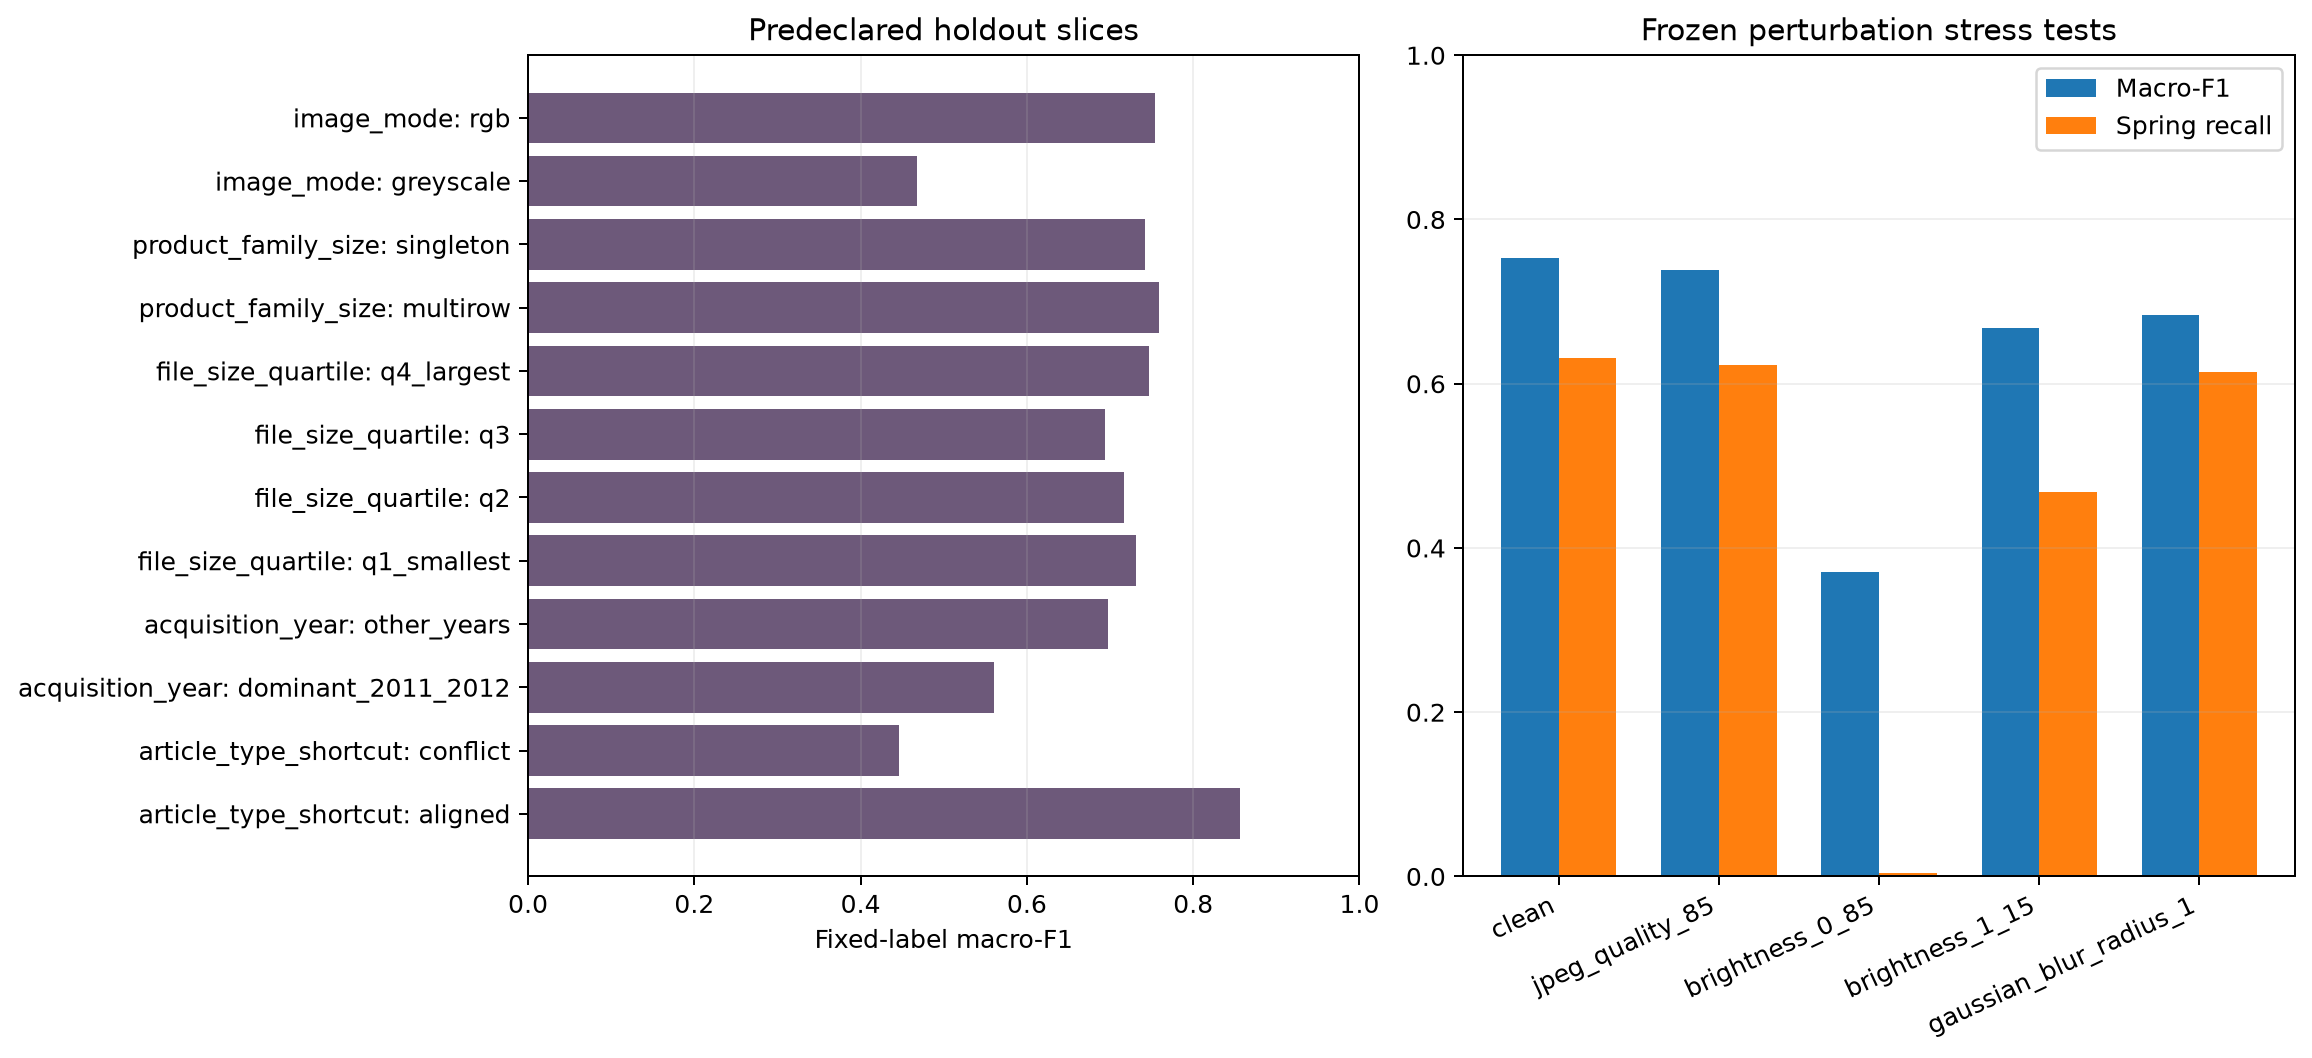

> **How to read this figure.** Bars below the clean reference expose sensitivity; the dark-image condition is the dominant failure and must not be hidden by the clean score.

In [12]:
robustness = pd.read_csv(EVIDENCE / "holdout_robustness_metrics.csv")
robust_columns = [
    "condition",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "spring_recall",
    "prediction_agreement_with_clean",
    "delta_macro_f1_vs_clean",
]
show_table(
    robustness.loc[:, robust_columns].round(4),
    "Read delta_macro_f1_vs_clean as the loss from the same frozen model under one "
    "synthetic condition; agreement shows how often labels change.",
)
show_figure(
    FIGURES / "holdout_slices_robustness.png",
    "Bars below the clean reference expose sensitivity; the dark-image condition is "
    "the dominant failure and must not be hidden by the clean score.",
)

**Interpretation.**

- **Compression:** JPEG quality 85 causes a moderate absolute macro-F1 drop of 0.0152, from 0.7534 to 0.7382. The core decision mostly survives ordinary recompression.
- **Blur and brightness:** radius-1 blur drops macro-F1 by 0.0694; brightness 1.15 drops it by 0.0859. These are material but smaller than the dark-image failure.
- **Critical failure:** brightness 0.85 reduces macro-F1 to 0.3712 (`−0.3822`) and Spring recall from 0.6309 to 0.0043. The strong asymmetry between darker and brighter inputs shows that clean performance is not robust to exposure change.
- **Decision:** deploy only with input-quality monitoring and a human-review path for dark, blurred, or shifted images. Do not present the clean holdout score as an unconditional service guarantee.
- **Limitation:** these are deterministic synthetic stress tests. They reveal sensitivity and rank risks, but they do not estimate the frequency or exact severity of real production shifts.

## 12. Errors and explainability limits

### 12.1 Review deterministic errors and development Grad-CAM evidence

Examples are selected by descending frozen confidence and ascending ID. Grad-CAM is retained as a spatial diagnostic, not a causal explanation.


,y_true,y_pred,count,mean_confidence,high_confidence_count
0,Fall,Summer,463,0.657,105
1,Summer,Fall,294,0.618,45
2,Winter,Summer,229,0.617,40
3,Summer,Winter,161,0.601,24
4,Fall,Winter,76,0.575,11
5,Spring,Summer,48,0.629,6
6,Winter,Fall,45,0.481,2
7,Spring,Fall,21,0.512,1
8,Spring,Winter,17,0.562,2
9,Summer,Spring,7,0.502,1


> **How to read this table.** Start with count to find common error directions, then inspect high-confidence count to find mistakes that confidence-based review can miss.

,id,y_true,y_pred,confidence,true_probability,articleType,article_type_shortcut
0,33054,Winter,Summer,0.992,0.003,Shirts,conflict
1,19296,Summer,Winter,0.992,0.004,Watches,conflict
2,51278,Fall,Winter,0.991,0.002,Sunglasses,conflict
3,26518,Spring,Summer,0.991,0.002,Shirts,conflict
4,38850,Fall,Summer,0.990,0.003,Tops,conflict
5,40530,Summer,Winter,0.990,0.001,Watches,conflict
6,38837,Fall,Summer,0.989,0.006,Dresses,conflict
7,19394,Summer,Fall,0.988,0.009,Jackets,conflict
8,27995,Winter,Summer,0.979,0.002,Briefs,conflict
9,27431,Winter,Summer,0.977,0.012,Tshirts,conflict


> **How to read this table.** These are deterministic examples selected by the recorded rule. Confidence is the predicted-class probability, not proof that a label is correct.

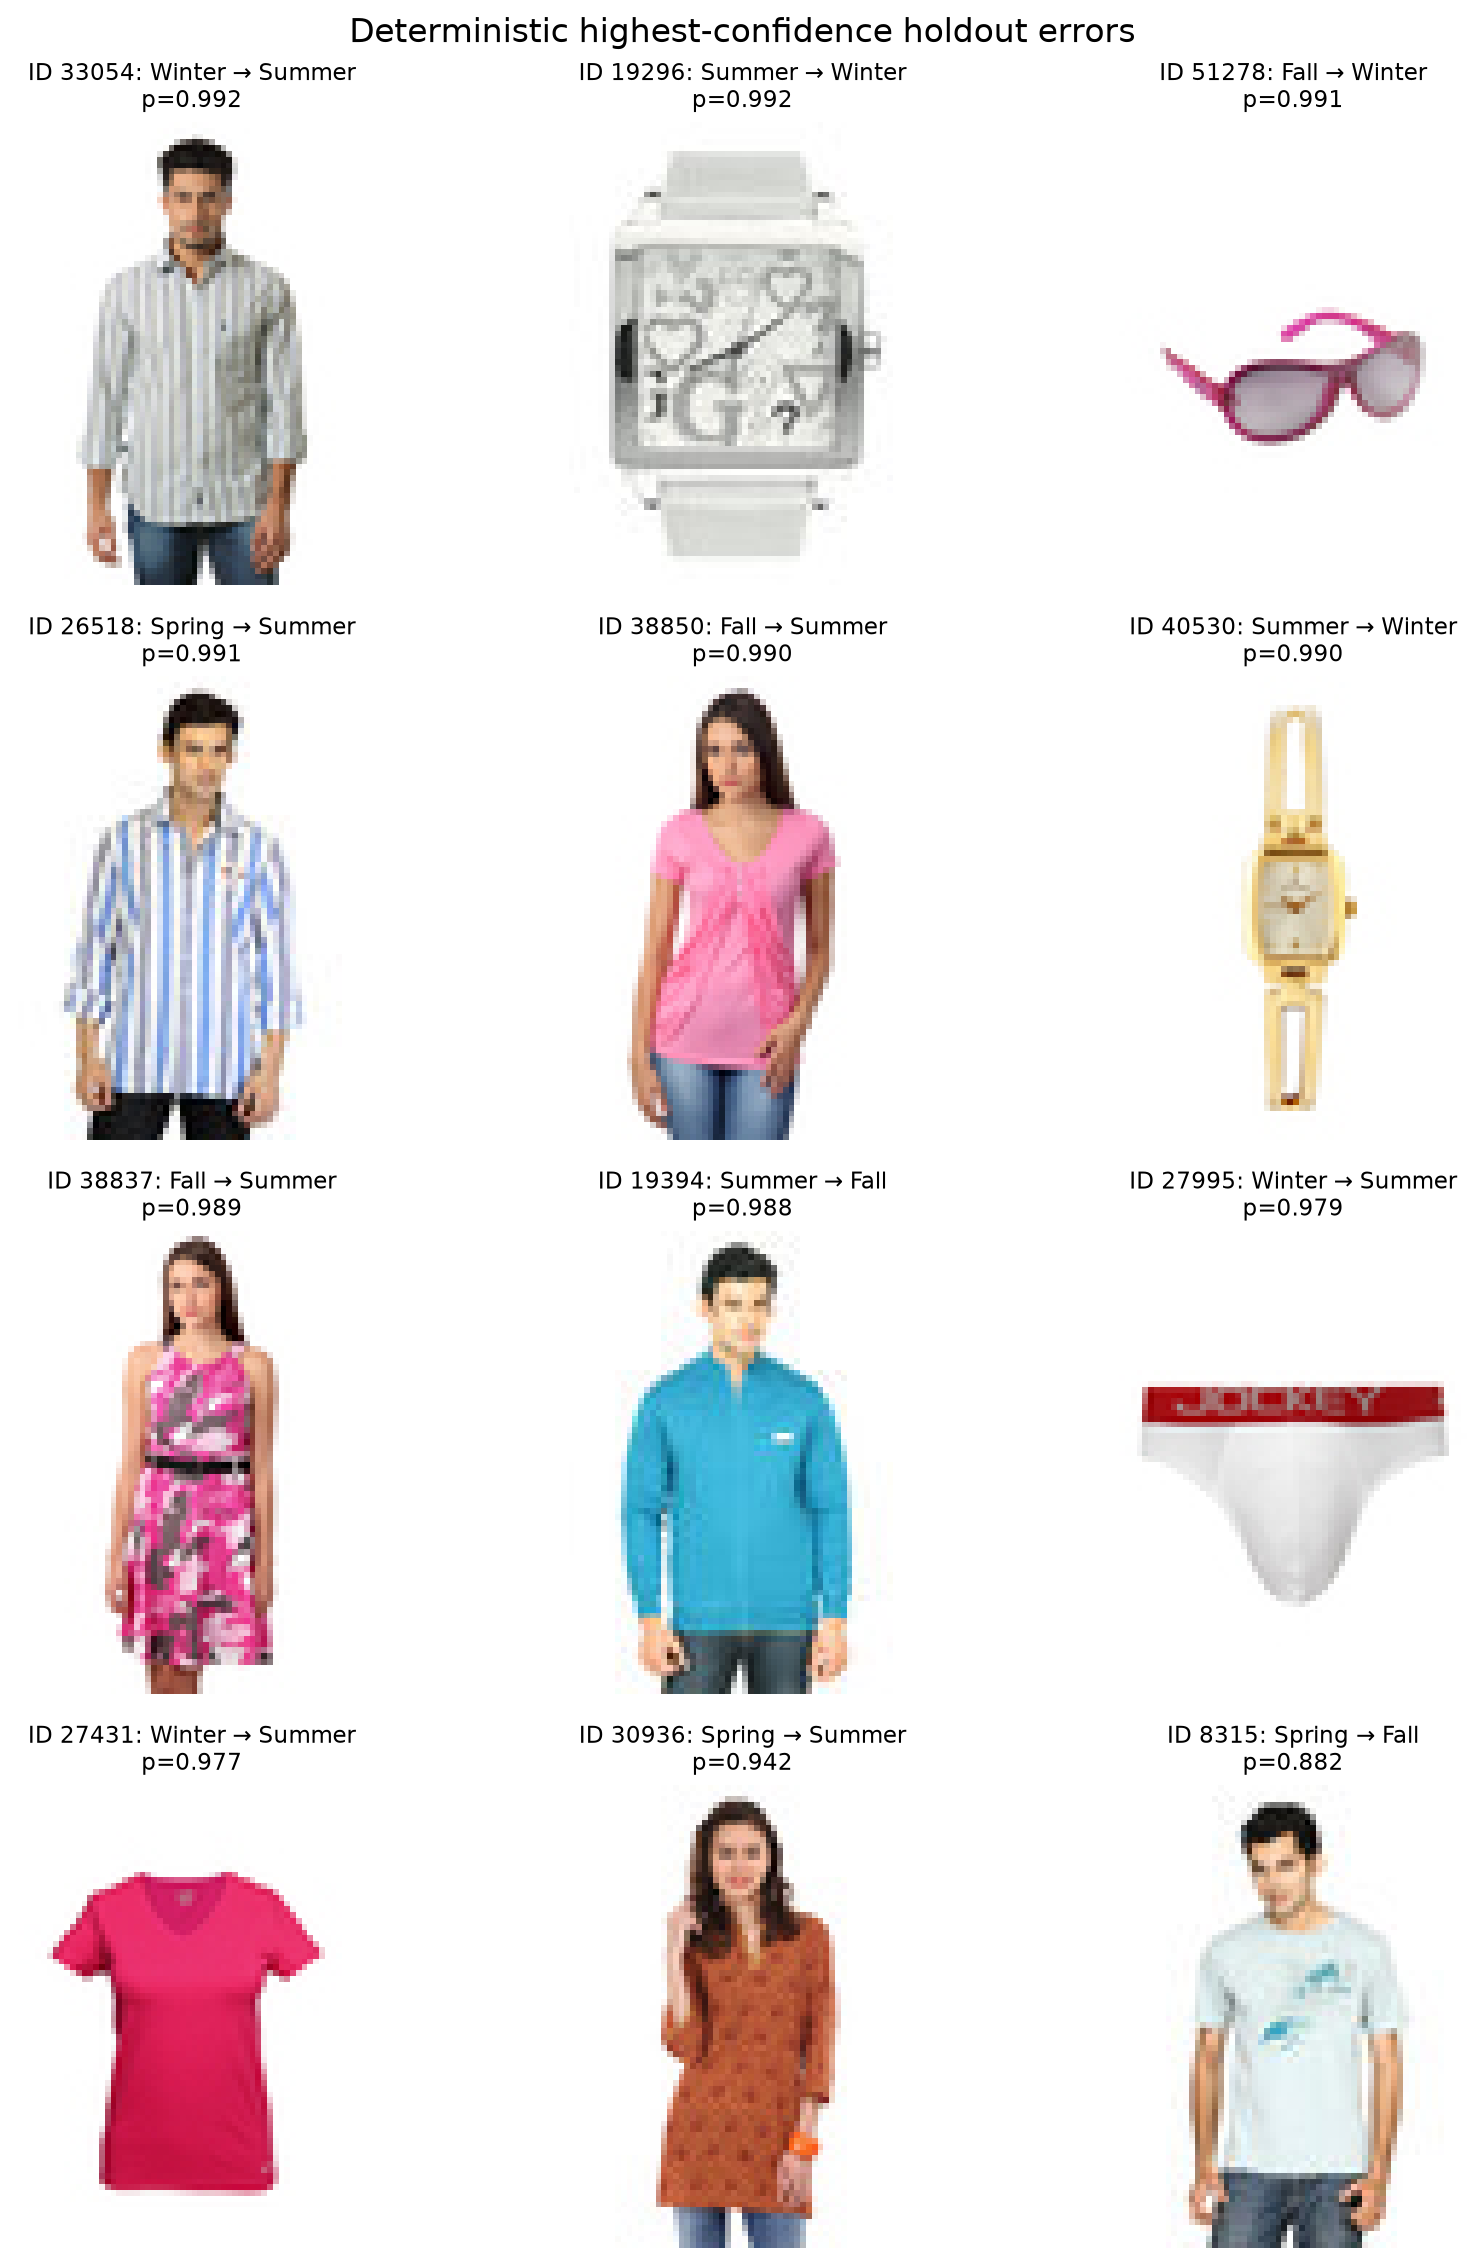

> **How to read this figure.** Read each image with its true and predicted Season; visual ambiguity is a hypothesis, not a causal explanation.

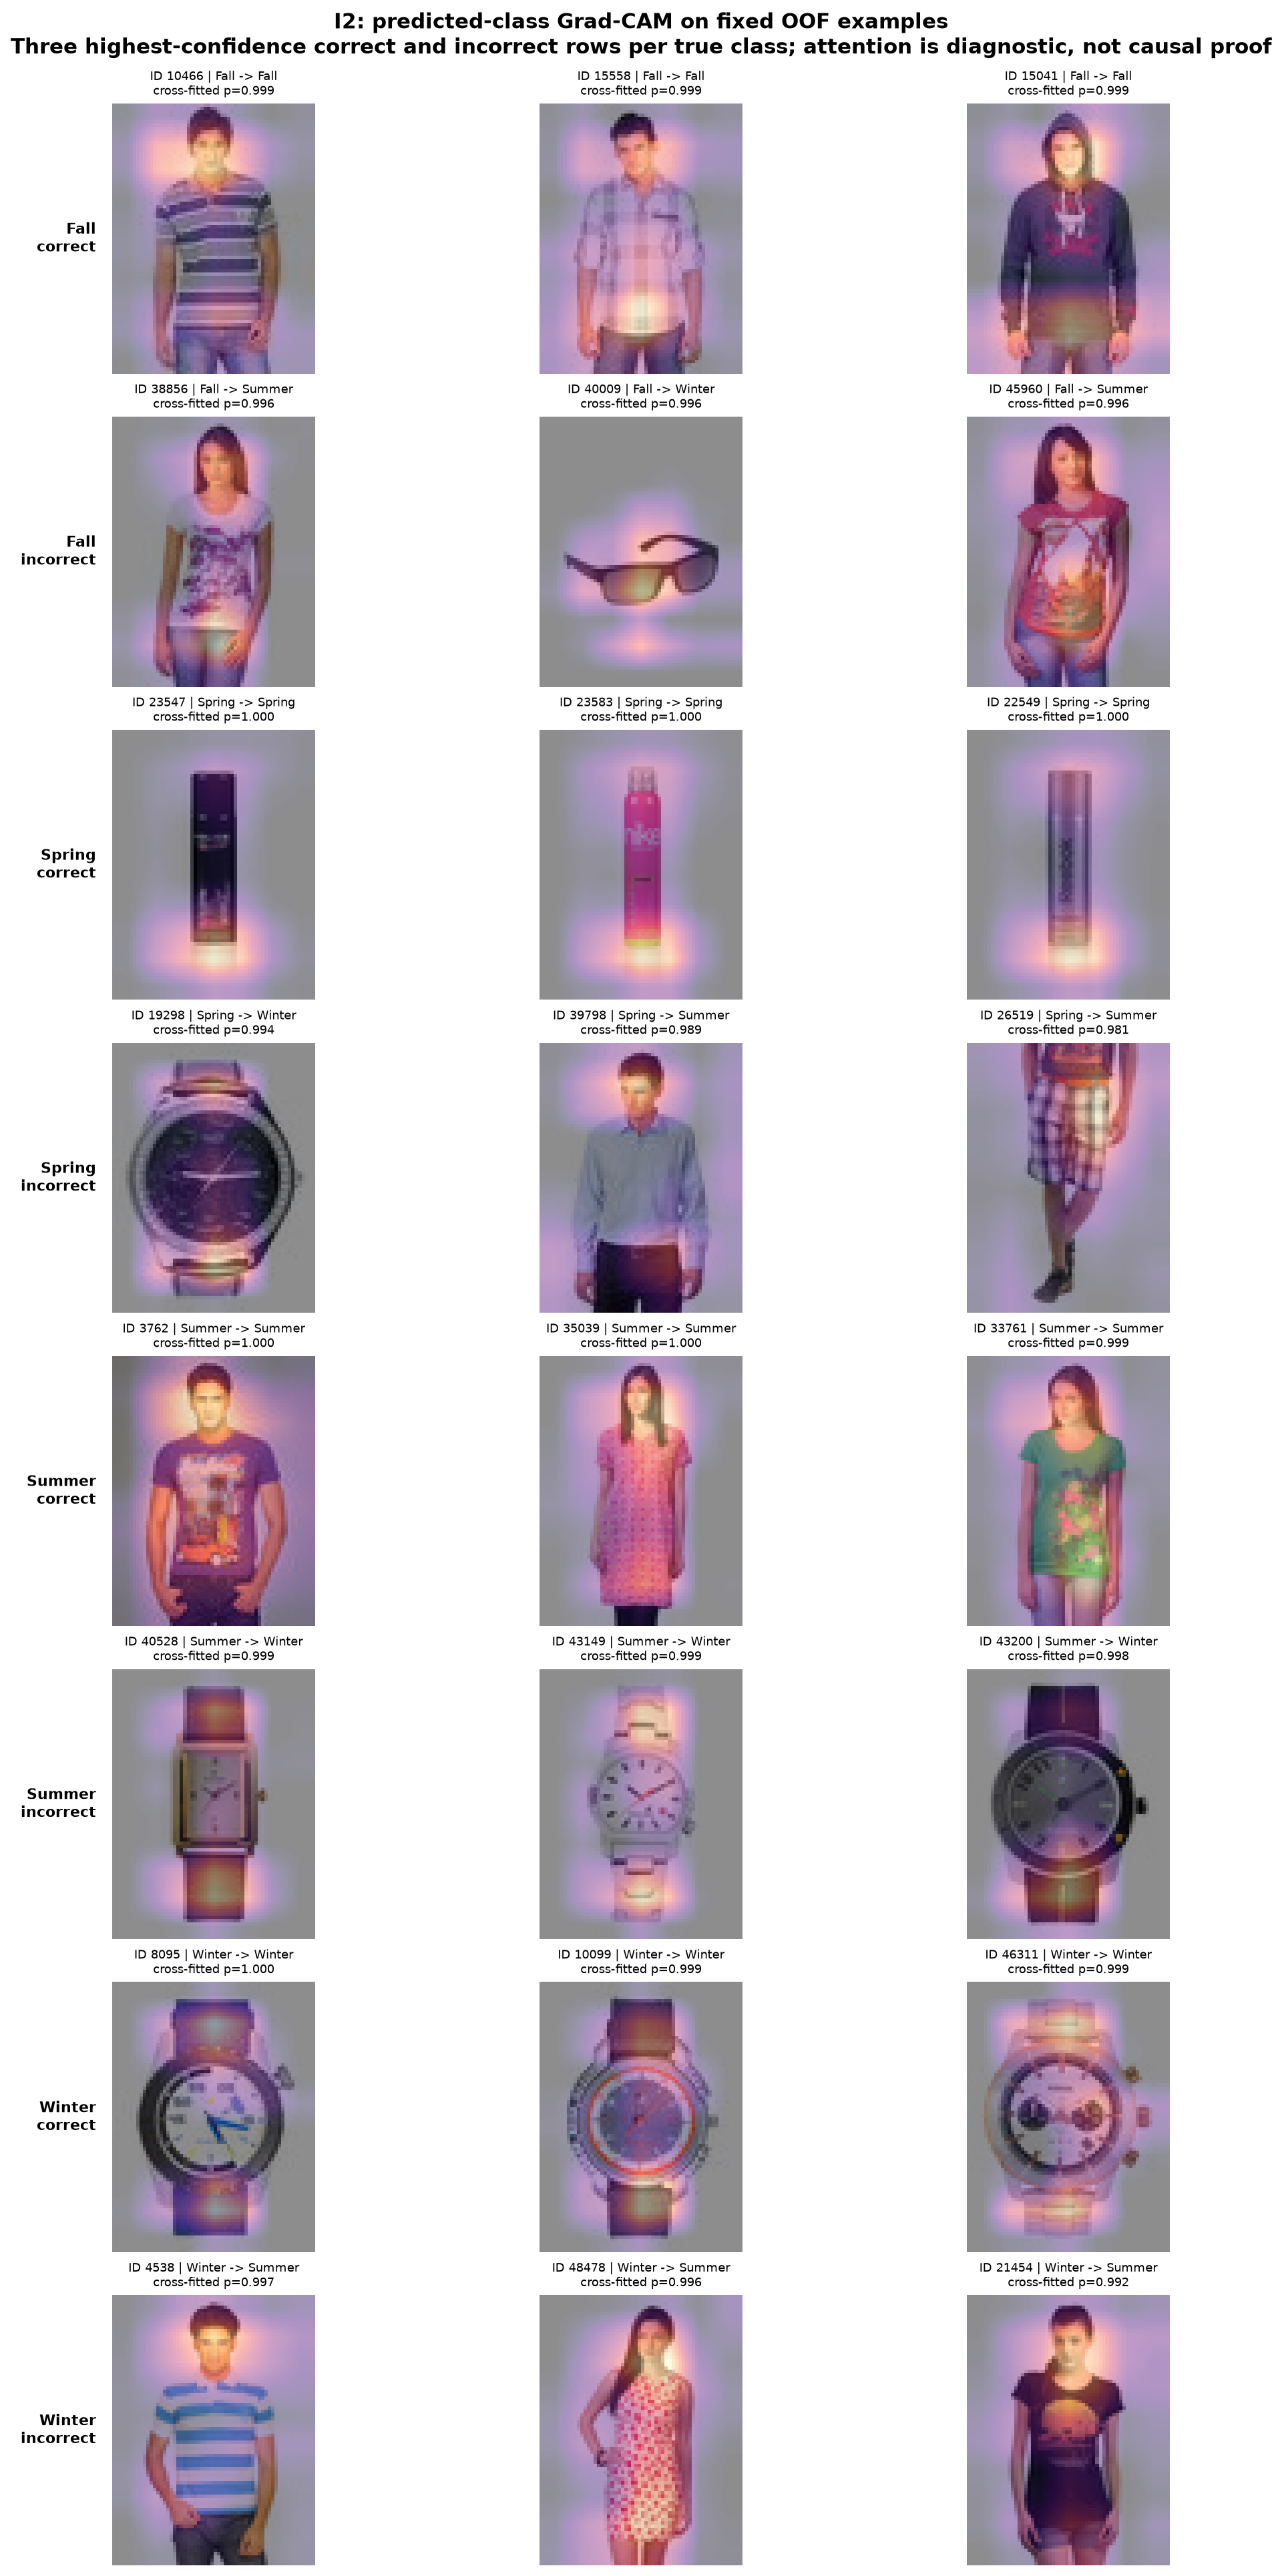

> **How to read this figure.** Grad-CAM marks regions that influence a class score in development examples; it does not prove that the highlighted object part caused the decision.

In [13]:
error_examples = pd.read_csv(EVIDENCE / "holdout_error_examples.csv")
show_table(
    error_routes.head(10).round({"mean_confidence": 3}),
    "Start with count to find common error directions, then inspect high-confidence "
    "count to find mistakes that confidence-based review can miss.",
)
show_table(
    error_examples.loc[
        :,
        [
            "id",
            "y_true",
            "y_pred",
            "confidence",
            "true_probability",
            "articleType",
            "article_type_shortcut",
        ],
    ].round(3),
    "These are deterministic examples selected by the recorded rule. Confidence is "
    "the predicted-class probability, not proof that a label is correct.",
)
show_figure(
    FIGURES / "holdout_error_examples.png",
    "Read each image with its true and predicted Season; visual ambiguity is a "
    "hypothesis, not a causal explanation.",
)
show_figure(
    ROOT / "results/figures/task2/gradcam_i2_contact_sheet.png",
    "Grad-CAM marks regions that influence a class score in development examples; it "
    "does not prove that the highlighted object part caused the decision.",
)

**Interpretation.**

- **Observed failures:** Fall → Summer accounts for 463 errors, including 105 high-confidence cases; Summer → Fall adds 294, including 45 high-confidence cases. High confidence therefore cannot be treated as certainty.
- **Holdout evidence:** the first figure and table show fixed holdout mistakes with IDs, labels, confidence, ArticleType, and shortcut status. They support a repeatable failure taxonomy instead of selected anecdotes.
- **Grad-CAM boundary:** the contact sheet is pre-holdout development evidence, not a heatmap fitted or selected from these holdout errors. Grad-CAM shows where the predicted-class score is sensitive, but it cannot prove that ArticleType, background, colour, or another region caused the decision.
- **Decision:** use examples and heatmaps for human investigation, input checks, and model-card limits. They cannot justify post-holdout architecture changes or causal claims.
- **Domain limit:** Season can depend on market, material, styling, and intended use that pixels alone may not reveal. Some errors may reflect an under-specified target rather than a simple vision defect.

## 13. Cost, coverage, and practical operation

### 13.1 Audit model size and measured inference cost

Single-image latency and batch holdout throughput answer different deployment questions and are reported separately.


In [14]:
deployment = pd.read_csv(EVIDENCE / "deployment_summary.csv")
blind_runtime = read_json(EVIDENCE / "blind_runtime.json")
runtime_table = pd.DataFrame(blind_runtime["runs"])
show_table(
    deployment.round(3),
    "Model size and single-image latency describe the frozen bundle on recorded "
    "hardware; they are not universal service-level promises.",
)
show_table(
    runtime_table.loc[
        :,
        [
            "dataset",
            "condition",
            "rows",
            "device",
            "runtime_seconds",
            "images_per_second",
            "prediction_failures",
        ],
    ].round(3),
    "Rows and images_per_second describe batch evaluation throughput. Compare only "
    "runs with the same device and condition.",
)

,candidate,parameter_count,bundle_bytes,development_cpu_end_to_end_median_ms,development_cuda_end_to_end_median_ms,holdout_clean_device,holdout_clean_runtime_seconds,holdout_clean_images_per_second,holdout_clean_prediction_failures,holdout_clean_peak_vram_bytes
0,I2,1206112,4856199,6.493,1.882,cpu,12.495,462.443,0,NaN


> **How to read this table.** Model size and single-image latency describe the frozen bundle on recorded hardware; they are not universal service-level promises.

,dataset,condition,rows,device,runtime_seconds,images_per_second,prediction_failures
0,internal_holdout,clean,5778,cpu,12.495,462.443,0
1,internal_holdout,jpeg_quality_85,5778,cpu,13.101,441.026,0
2,internal_holdout,brightness_0_85,5778,cpu,12.765,452.657,0
3,internal_holdout,brightness_1_15,5778,cpu,14.039,411.570,0
4,internal_holdout,gaussian_blur_radius_1,5778,cpu,14.875,388.449,0
5,teacher_test,clean,5829,cpu,14.284,408.074,0


> **How to read this table.** Rows and images_per_second describe batch evaluation throughput. Compare only runs with the same device and condition.

**Interpretation.**

- **Size:** I2 has 1,206,112 parameters and a 4,856,199-byte bundle (about 4.86 MB), which is small enough for practical catalogue delivery.
- **Single-image latency:** prior development measurements are about 6.49 ms on CPU and 1.88 ms on the available CUDA GPU. These include the measured local path, not a network request or multi-user service.
- **Batch evaluation:** clean holdout inference processed 5,778 images in 12.49 seconds on CPU, about 462 images/s, with zero prediction failures. This supports offline catalogue batches and the 5,829-row teacher output.
- **Decision:** the compact model is operationally preferable to a near-tied large reference when quality is similar. Record hardware and batch size whenever latency is quoted.
- **Limitation:** timing is machine-specific and cannot be promised as universal latency. Blank CPU peak-VRAM is “not applicable/not measured,” not zero GPU memory use.

## 14. Academic sources used in training and evaluation

### 14.1 Separate repeated training foundations from evaluation foundations

The rows follow the notebook's reading order. `Training (repeated)` appears only because Sections 2, 3, and 10 explicitly discuss how the frozen model was selected. It provides the original foundation for those already-completed training methods; it does not reopen training or validate the holdout score. `Evaluation` supports the methods used after predictions were frozen. Each row states both the exact project use and the claim boundary.

In [15]:
literature = pd.DataFrame(
    [
        [
            "Training (repeated)",
            "Dalal & Triggs (2005)",
            "HOG descriptor",
            "Section 3 B1 shape features",
            "https://lear.inrialpes.fr/people/triggs/pubs/Dalal-cvpr05.pdf",
            "Original task was human detection; no Fashion score transfers",
        ],
        [
            "Training (repeated)",
            "Cortes & Vapnik (1995)",
            "Support-vector machine",
            "Section 3 B1 classifier",
            "https://doi.org/10.1007/BF00994018",
            "Supports maximum-margin learning, not this multiclass result",
        ],
        [
            "Training (repeated)",
            "LeCun et al. (1998)",
            "Convolutional neural network",
            "Section 3 C1 SmallCNN",
            "https://doi.org/10.1109/5.726791",
            "General CNN foundation; C1 is project-specific",
        ],
        [
            "Training (repeated)",
            "He et al. (2016)",
            "Residual network",
            "Section 3 C2 and P* ResNet18",
            (
                "https://openaccess.thecvf.com/content_cvpr_2016/html/"
                "He_Deep_Residual_Learning_CVPR_2016_paper.html"
            ),
            "Architecture source; greater capacity did not guarantee a win",
        ],
        [
            "Training (repeated)",
            "Shorten & Khoshgoftaar (2019)",
            "Image augmentation",
            "Section 10 colour-jitter reflection",
            "https://doi.org/10.1186/s40537-019-0197-0",
            "Motivates testing; this project's A1 result was negative",
        ],
        [
            "Training (repeated)",
            "Cui et al. (2019)",
            "Effective-number class-balanced loss",
            "Section 3 I1 intervention",
            (
                "https://openaccess.thecvf.com/content_CVPR_2019/html/"
                "Cui_Class-Balanced_Loss_Based_on_Effective_Number_of_Samples_"
                "CVPR_2019_paper.html"
            ),
            "Motivates I1; measured evidence correctly rejected it",
        ],
        [
            "Training (repeated)",
            "Caruana (1997)",
            "Multi-task learning",
            "Sections 2–3 I2 ArticleType auxiliary head",
            "https://doi.org/10.1023/A:1007379606734",
            "Motivates related-task transfer; gain must be measured here",
        ],
        [
            "Training (repeated)",
            "Deng et al. (2009)",
            "ImageNet pretraining source",
            "Section 3 P* benchmark boundary",
            "https://doi.org/10.1109/CVPR.2009.5206848",
            "Explains weight origin; P* is final-ineligible",
        ],
        [
            "Training (repeated)",
            "Kolisnik et al. (2021)",
            "Hierarchical fashion prediction",
            "ArticleType/Season related-label rationale",
            "https://doi.org/10.1016/j.eswa.2021.115195",
            "Different labels and split; raw scores are not comparable",
        ],
        [
            "Evaluation",
            "Sokolova & Lapalme (2009)",
            "Classification performance measures",
            "Sections 6–7 macro-F1 and per-class metrics",
            "https://doi.org/10.1016/j.ipm.2009.03.002",
            "Metric definitions do not decide deployment utility",
        ],
        [
            "Evaluation",
            "Bengio & Grandvalet (2004)",
            "K-fold uncertainty boundary",
            "Development OOF comparison limitation",
            "https://www.jmlr.org/papers/v5/grandvalet04a.html",
            "Naive fold variance is not a universal unbiased estimator",
        ],
        [
            "Evaluation",
            "Field & Welsh (2007)",
            "Cluster bootstrap",
            "Section 8 product-family resampling",
            "https://doi.org/10.1111/j.1467-9868.2007.00593.x",
            "Groups are conservative proxies, not verified SKUs",
        ],
        [
            "Evaluation",
            "Guo et al. (2017)",
            "Temperature scaling",
            "Section 9 calibration",
            "https://proceedings.mlr.press/v70/guo17a.html",
            "Calibration can change under distribution shift",
        ],
        [
            "Evaluation",
            "Geifman & El-Yaniv (2017)",
            "Selective classification",
            "Section 9 risk-coverage review",
            (
                "https://papers.neurips.cc/paper_files/paper/2017/hash/"
                "4a8423d5e91fda00bb7e46540e2b0cf1-Abstract.html"
            ),
            "Diagnostic curve does not select a business threshold",
        ],
        [
            "Evaluation",
            "Hendrycks & Dietterich (2019)",
            "Common-corruption robustness",
            "Section 11 JPEG/blur/brightness tests",
            "https://arxiv.org/abs/1903.12261",
            "Synthetic tests do not estimate production frequency",
        ],
        [
            "Evaluation",
            "Selvaraju et al. (2017)",
            "Grad-CAM",
            "Section 12 spatial failure review",
            (
                "https://openaccess.thecvf.com/content_iccv_2017/html/"
                "Selvaraju_Grad-CAM_Visual_Explanations_ICCV_2017_paper.html"
            ),
            "Post-hoc heatmaps are not causal explanations",
        ],
        [
            "Evaluation",
            "Adebayo et al. (2018)",
            "Saliency sanity checks",
            "Section 12 explainability limit",
            (
                "https://papers.neurips.cc/paper/2018/hash/"
                "294a8ed24b1ad22ec2e7efea049b8737-Abstract.html"
            ),
            "Visual plausibility alone is not validation",
        ],
        [
            "Evaluation",
            "Ovadia et al. (2019)",
            "Uncertainty under shift",
            "Sections 9 and 11 confidence warning",
            (
                "https://papers.neurips.cc/paper_files/paper/2019/hash/"
                "8558cb408c1d76621371888657d2eb1d-Abstract.html"
            ),
            "Different tasks and models; methodological warning only",
        ],
        [
            "Evaluation",
            "Koh et al. (2021)",
            "Distribution-shift evaluation",
            "Sections 10–11 slices and robustness",
            "https://proceedings.mlr.press/v139/koh21a.html",
            "No direct Season benchmark or transferable score",
        ],
    ],
    columns=["Scope", "Paper", "Method", "Used here", "Source", "Boundary"],
)
assert set(literature["Scope"]) == {"Training (repeated)", "Evaluation"}
show_table(
    HTML(
        literature.to_html(
            index=False,
            render_links=True,
            escape=True,
        )
    ),
    "Scope says whether a paper motivated training or evaluation. Used here gives "
    "the exact project connection; Boundary prevents claims beyond that evidence.",
)

Scope,Paper,Method,Used here,Source,Boundary
Training (repeated),Dalal & Triggs (2005),HOG descriptor,Section 3 B1 shape features,https://lear.inrialpes.fr/people/triggs/pubs/Dalal-cvpr05.pdf,Original task was human detection; no Fashion score transfers
Training (repeated),Cortes & Vapnik (1995),Support-vector machine,Section 3 B1 classifier,https://doi.org/10.1007/BF00994018,"Supports maximum-margin learning, not this multiclass result"
Training (repeated),LeCun et al. (1998),Convolutional neural network,Section 3 C1 SmallCNN,https://doi.org/10.1109/5.726791,General CNN foundation; C1 is project-specific
Training (repeated),He et al. (2016),Residual network,Section 3 C2 and P* ResNet18,https://openaccess.thecvf.com/content_cvpr_2016/html/He_Deep_Residual_Learning_CVPR_2016_paper.html,Architecture source; greater capacity did not guarantee a win
Training (repeated),Shorten & Khoshgoftaar (2019),Image augmentation,Section 10 colour-jitter reflection,https://doi.org/10.1186/s40537-019-0197-0,Motivates testing; this project's A1 result was negative
Training (repeated),Cui et al. (2019),Effective-number class-balanced loss,Section 3 I1 intervention,https://openaccess.thecvf.com/content_CVPR_2019/html/Cui_Class-Balanced_Loss_Based_on_Effective_Number_of_Samples_CVPR_2019_paper.html,Motivates I1; measured evidence correctly rejected it
Training (repeated),Caruana (1997),Multi-task learning,Sections 2–3 I2 ArticleType auxiliary head,https://doi.org/10.1023/A:1007379606734,Motivates related-task transfer; gain must be measured here
Training (repeated),Deng et al. (2009),ImageNet pretraining source,Section 3 P* benchmark boundary,https://doi.org/10.1109/CVPR.2009.5206848,Explains weight origin; P* is final-ineligible
Training (repeated),Kolisnik et al. (2021),Hierarchical fashion prediction,ArticleType/Season related-label rationale,https://doi.org/10.1016/j.eswa.2021.115195,Different labels and split; raw scores are not comparable
Evaluation,Sokolova & Lapalme (2009),Classification performance measures,Sections 6–7 macro-F1 and per-class metrics,https://doi.org/10.1016/j.ipm.2009.03.002,Metric definitions do not decide deployment utility


> **How to read this table.** Scope says whether a paper motivated training or evaluation. Used here gives the exact project connection; Boundary prevents claims beyond that evidence.

**Interpretation.**

- **Training sources are repeated, not reused:** the first nine rows exist only because this evaluation notebook reconstructs B1, C1/C2, I1, I2, augmentation, and P*. They explain each method's origin; they neither retrain the model nor prove its holdout result. MobileNetV3 and AdamW stay in Notebook 03 because Notebook 06 does not analyse them.
- **Evaluation sources support the measurement design:** Sokolova and Lapalme support class-sensitive metrics; Bengio and Grandvalet limit naive cross-validation variance claims; Field and Welsh support family-block resampling; Guo et al. support temperature scaling; Geifman and El-Yaniv support risk-coverage analysis; Hendrycks and Dietterich support common-corruption tests.
- **Explanation and shift boundary:** Grad-CAM and its sanity-check paper prevent a plausible heatmap from becoming a causal claim. Ovadia et al. and WILDS motivate uncertainty, slice, and robustness reporting under shift, but provide no directly comparable Season score.
- **Correction:** the verified Field and Welsh DOI is `10.1111/j.1467-9868.2007.00593.x`. The earlier `00602` suffix in this notebook was incorrect and has been removed.
- **Decision:** use papers to justify *why a method was tested* and project artifacts to justify *what happened*. No published score is ranked against this project's macro-F1 because the target, split, inputs, and training rules differ.

## 15. Ultimate judgement and artifact audit

### 15.1 State the deployment decision and verify traceability

The judgement combines discrimination, uncertainty, calibration, slices, robustness, cost, failures, and intended use.


In [16]:
judgement = read_json(EVIDENCE / "ultimate_judgement.json")
verified = load_verified_final_evaluation()
final_summary = pd.DataFrame(
    [
        ["Decision", judgement["ultimate_judgement"]],
        ["Holdout macro-F1", judgement["independent_holdout_macro_f1"]],
        ["Holdout balanced accuracy", judgement["independent_holdout_balanced_accuracy"]],
        ["Development → holdout change", judgement["development_to_holdout_macro_f1_change"]],
        ["I2−B0 95% interval", judgement["i2_minus_b0_macro_f1_interval_95"]],
        ["Model changed after unlock", verified["model"]["model_changed_after_unlock"]],
        ["Tracked evaluation artifacts", len(verified["artifacts"])],
        ["Teacher test scored", verified["official_test"]["scored"]],
    ],
    columns=["Judgement field", "Evidence"],
)
show_table(
    final_summary,
    "This is the final evidence chain: quality, uncertainty, unchanged frozen model, "
    "artifact coverage, and the unscored teacher-test boundary.",
)
print(
    {
        "manifest": "results/evidence/task2/final_evaluation/evaluation_manifest.json",
        "status": verified["status"],
    }
)

,Judgement field,Evidence
0,Decision,conditionally_viable_for_catalogue_decision_su...
1,Holdout macro-F1,0.753385
2,Holdout balanced accuracy,0.719706
3,Development → holdout change,0.000698
4,I2−B0 95% interval,"[0.5666774590701896, 0.6072286677590603]"
5,Model changed after unlock,False
6,Tracked evaluation artifacts,23
7,Teacher test scored,False


> **How to read this table.** This is the final evidence chain: quality, uncertainty, unchanged frozen model, artifact coverage, and the unscored teacher-test boundary.

{'manifest': 'results/evidence/task2/final_evaluation/evaluation_manifest.json', 'status': 'complete'}


**Interpretation.**

- **Ultimate judgement:** frozen I2 is **conditionally viable for catalogue decision support**, not fully automatic truth. It achieves 0.7534 holdout macro-F1 and 0.7197 balanced accuracy, with a family-blocked I2-minus-B0 interval entirely above zero.
- **Why accept it:** development-to-holdout change is only `+0.0007`, calibration improves without changing labels, the bundle is compact, batch throughput is practical, and all holdout/test images receive predictions.
- **Why condition it:** conflict macro-F1 is 0.4462, dark-image macro-F1 is 0.3712, Spring recall can collapse under shift, and Season itself is contextual. These failures are too large for unreviewed automation.
- **Operational rule:** monitor image quality and data mix, route low-confidence or shifted cases to a person, preserve model/config hashes, and collect new labelled data before any future update. This holdout result must not trigger retraining or threshold tuning.
- **Teacher output:** `results/season_test_predictions.csv` contains the final 5,829 `id,season` predictions. No teacher-test accuracy is claimed because teacher-test Season labels are unavailable.
- **Trace and precision:** `evaluation_manifest.json` hashes the final evidence. Full-precision metrics remain in CSV/JSON; the notebook and HTML round only for readability.